# Stage 1 — Few-Shot Classification Baselines

**MNIST · CIFAR-10 · Mini-ImageNet | frozen pretrained embeddings**

This notebook presents the Stage 1 baselines of the project (see `_docs/bigPicture.txt`):

1. **Prototype classifier** — class prototype = mean support embedding; nearest-prototype decision (cosine primary, Euclidean ablation).
2. **Linear probe** — PyTorch `nn.Linear` trained with `CrossEntropyLoss` on the support set.
3. **Zero-shot CLIP** — image–text cosine similarity with dataset-specific prompts (single prompt + prompt-ensemble ablation).

Two evaluation protocols:

- **Episodic**: 5-way, K ∈ {1, 5}, 15 queries, 600 episodes → mean accuracy ± 95% CI. Mini-ImageNet uses the 20 Ravi & Larochelle *test* classes; MNIST/CIFAR-10 included for comparison.
- **Simple K-shot**: all classes, K ∈ {1, 5, 10} support per class (drawn from the train split), full test set, 10 seeds → mean ± std.

Everything downstream of the frozen encoders is reproducible from committed artifacts: fixed episode index files (`results/artifacts/episodes/`), cached embeddings, class prototypes and CLIP text embeddings — the exact inputs stages 2–3 (Flow Matching) will reuse.

## 1 · Environment & configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import pandas as pd

from src.utils import load_config

pd.set_option("display.precision", 2)

with open(REPO / "results" / "runtime_summary.json") as f:
    runtime = json.load(f)
print("Runtime:", json.dumps(runtime, indent=2))
cfg = load_config()
print("\nEpisodic protocol:", cfg["episodic"])
print("Simple protocol:  ", cfg["simple"])

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Episodic protocol: {'n_way': 5, 'shots': [1, 5], 'n_query': 15, 'n_episodes': 600, 'seed': 42}
Simple protocol:   {'shots': [1, 5, 10], 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}


All experiments ran on the machine above (AMD RX 7900 XTX, torch+ROCm). Backbones — all **frozen**, used only as feature extractors (ADR 0001):

| Backbone | Source | Dim |
|---|---|---|
| CLIP ViT-B/32 (primary) | official OpenAI `clip` | 512 |
| DINOv2 ViT-S/14 | `facebook/dinov2-small` | 384 |
| ResNet-50 (ImageNet) | torchvision, penultimate layer | 2048 |

## 2 · Datasets & fixed episodes

| Dataset | Classes (episodic pool) | Images | Notes |
|---|---|---|---|
| MNIST | 10 (test split) | 10,000 | grayscale → 3-channel |
| CIFAR-10 | 10 (test split) | 10,000 | |
| Mini-ImageNet | 20 R&L **test** classes | 13,000 (650/class) | `timm/mini-imagenet`, re-partitioned by the canonical Ravi & Larochelle 64/16/20 *class* split (`config/mini_imagenet_splits.json`) |

Episode support/query indices were sampled **once** (seed 42) and saved to `results/artifacts/episodes/` (ADR 0002); every classifier — and stages 2–3 later — evaluates on these exact files. Below: episode 0 of the 5-way 5-shot file for each dataset.

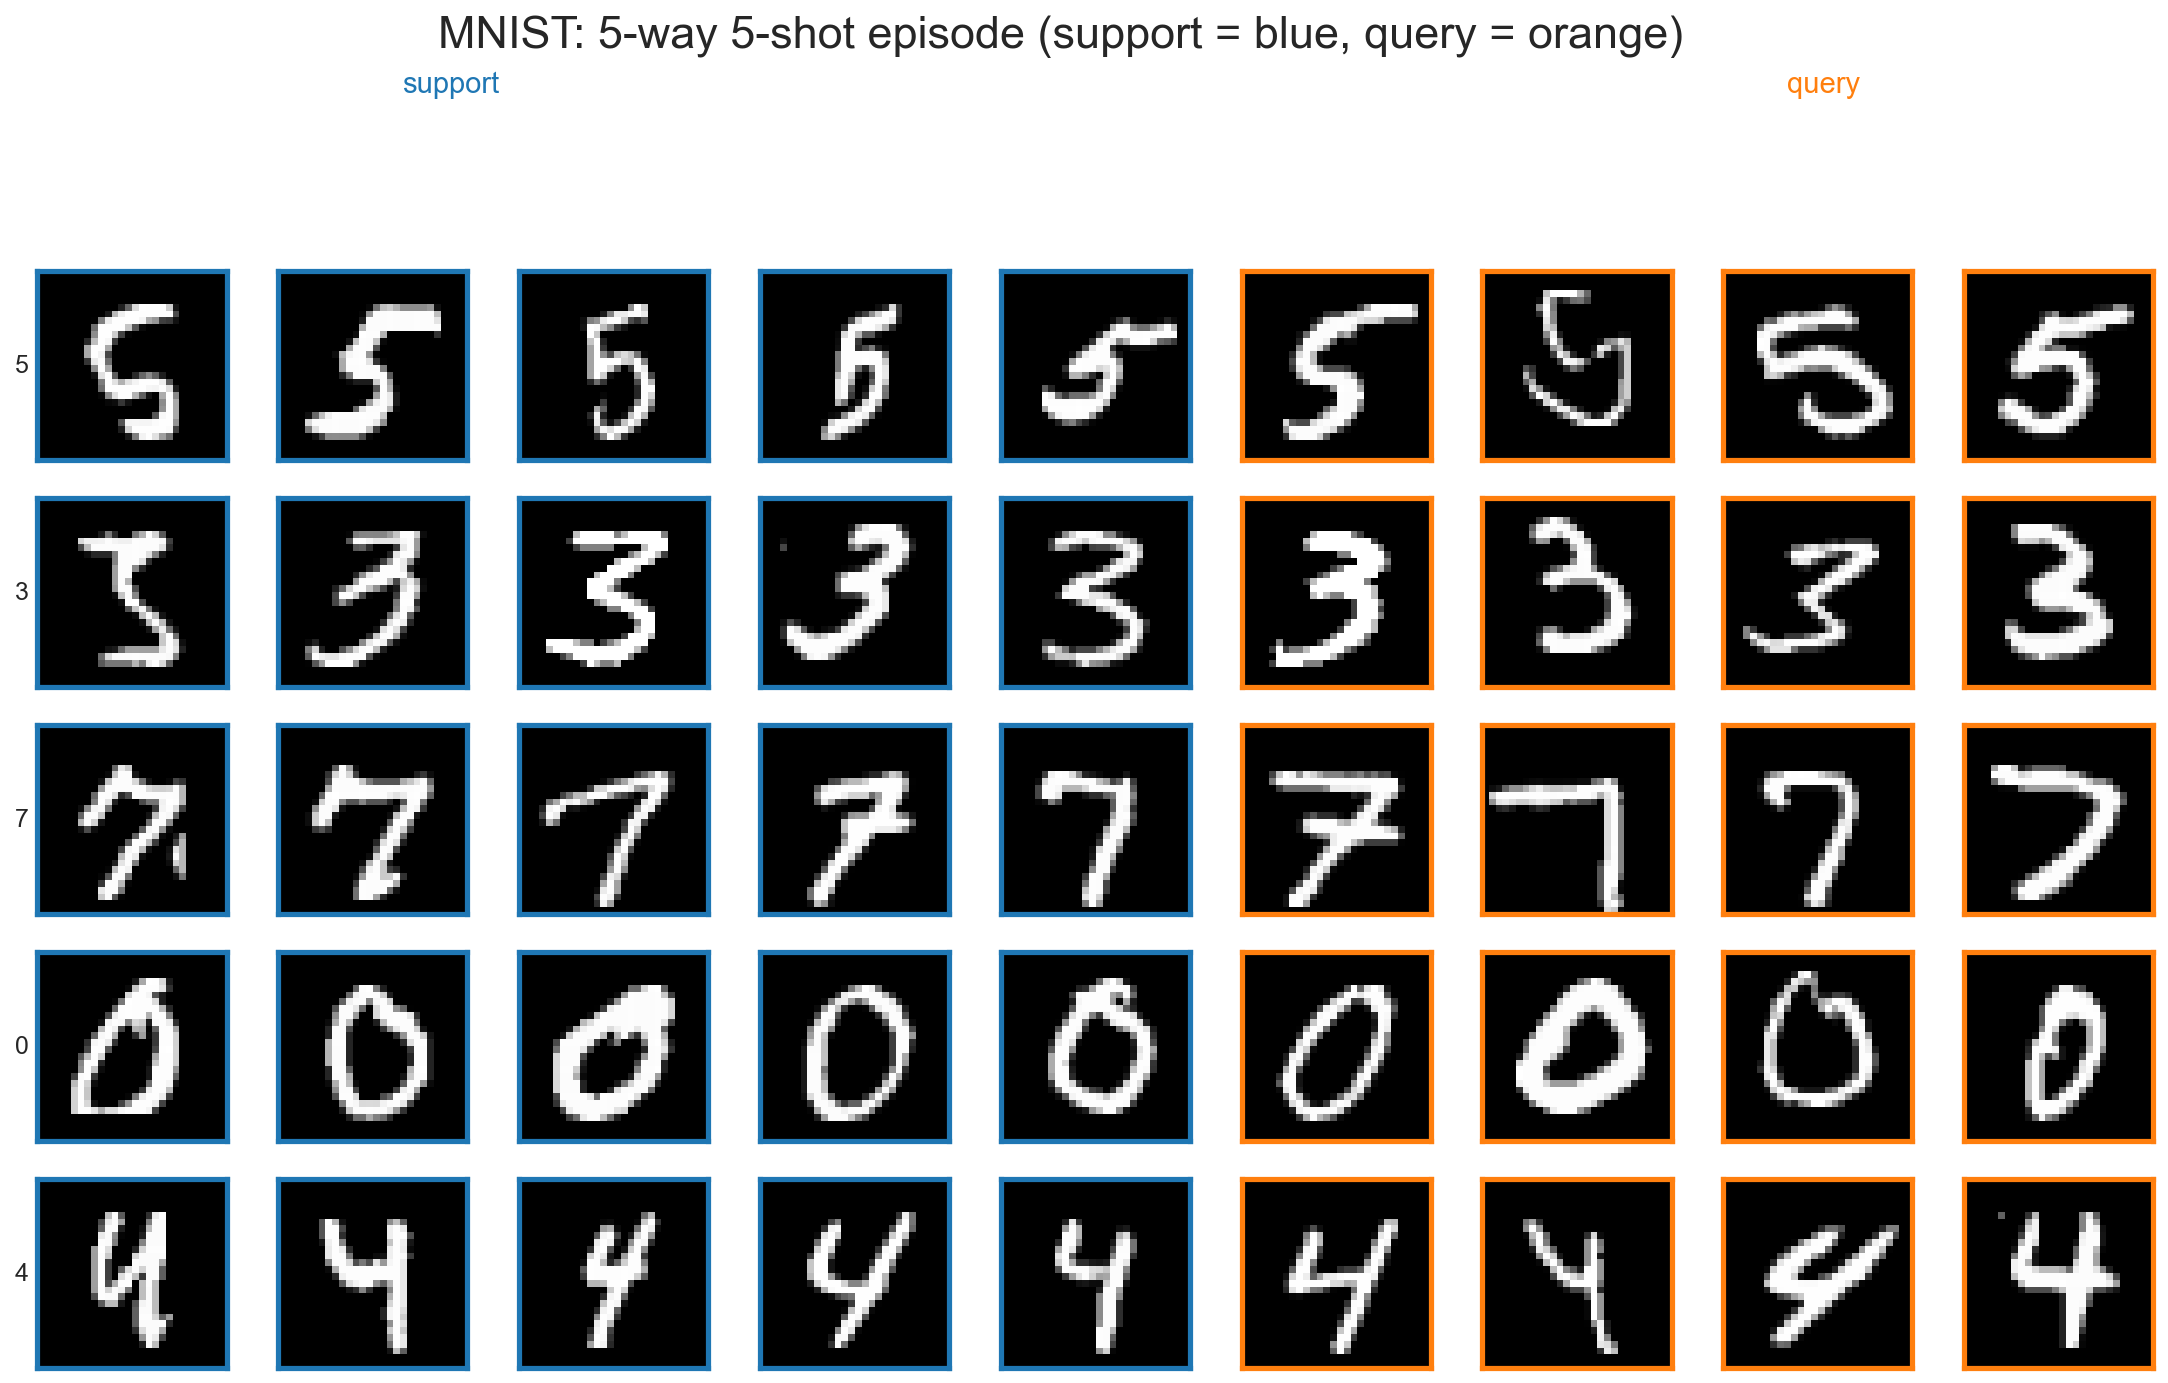

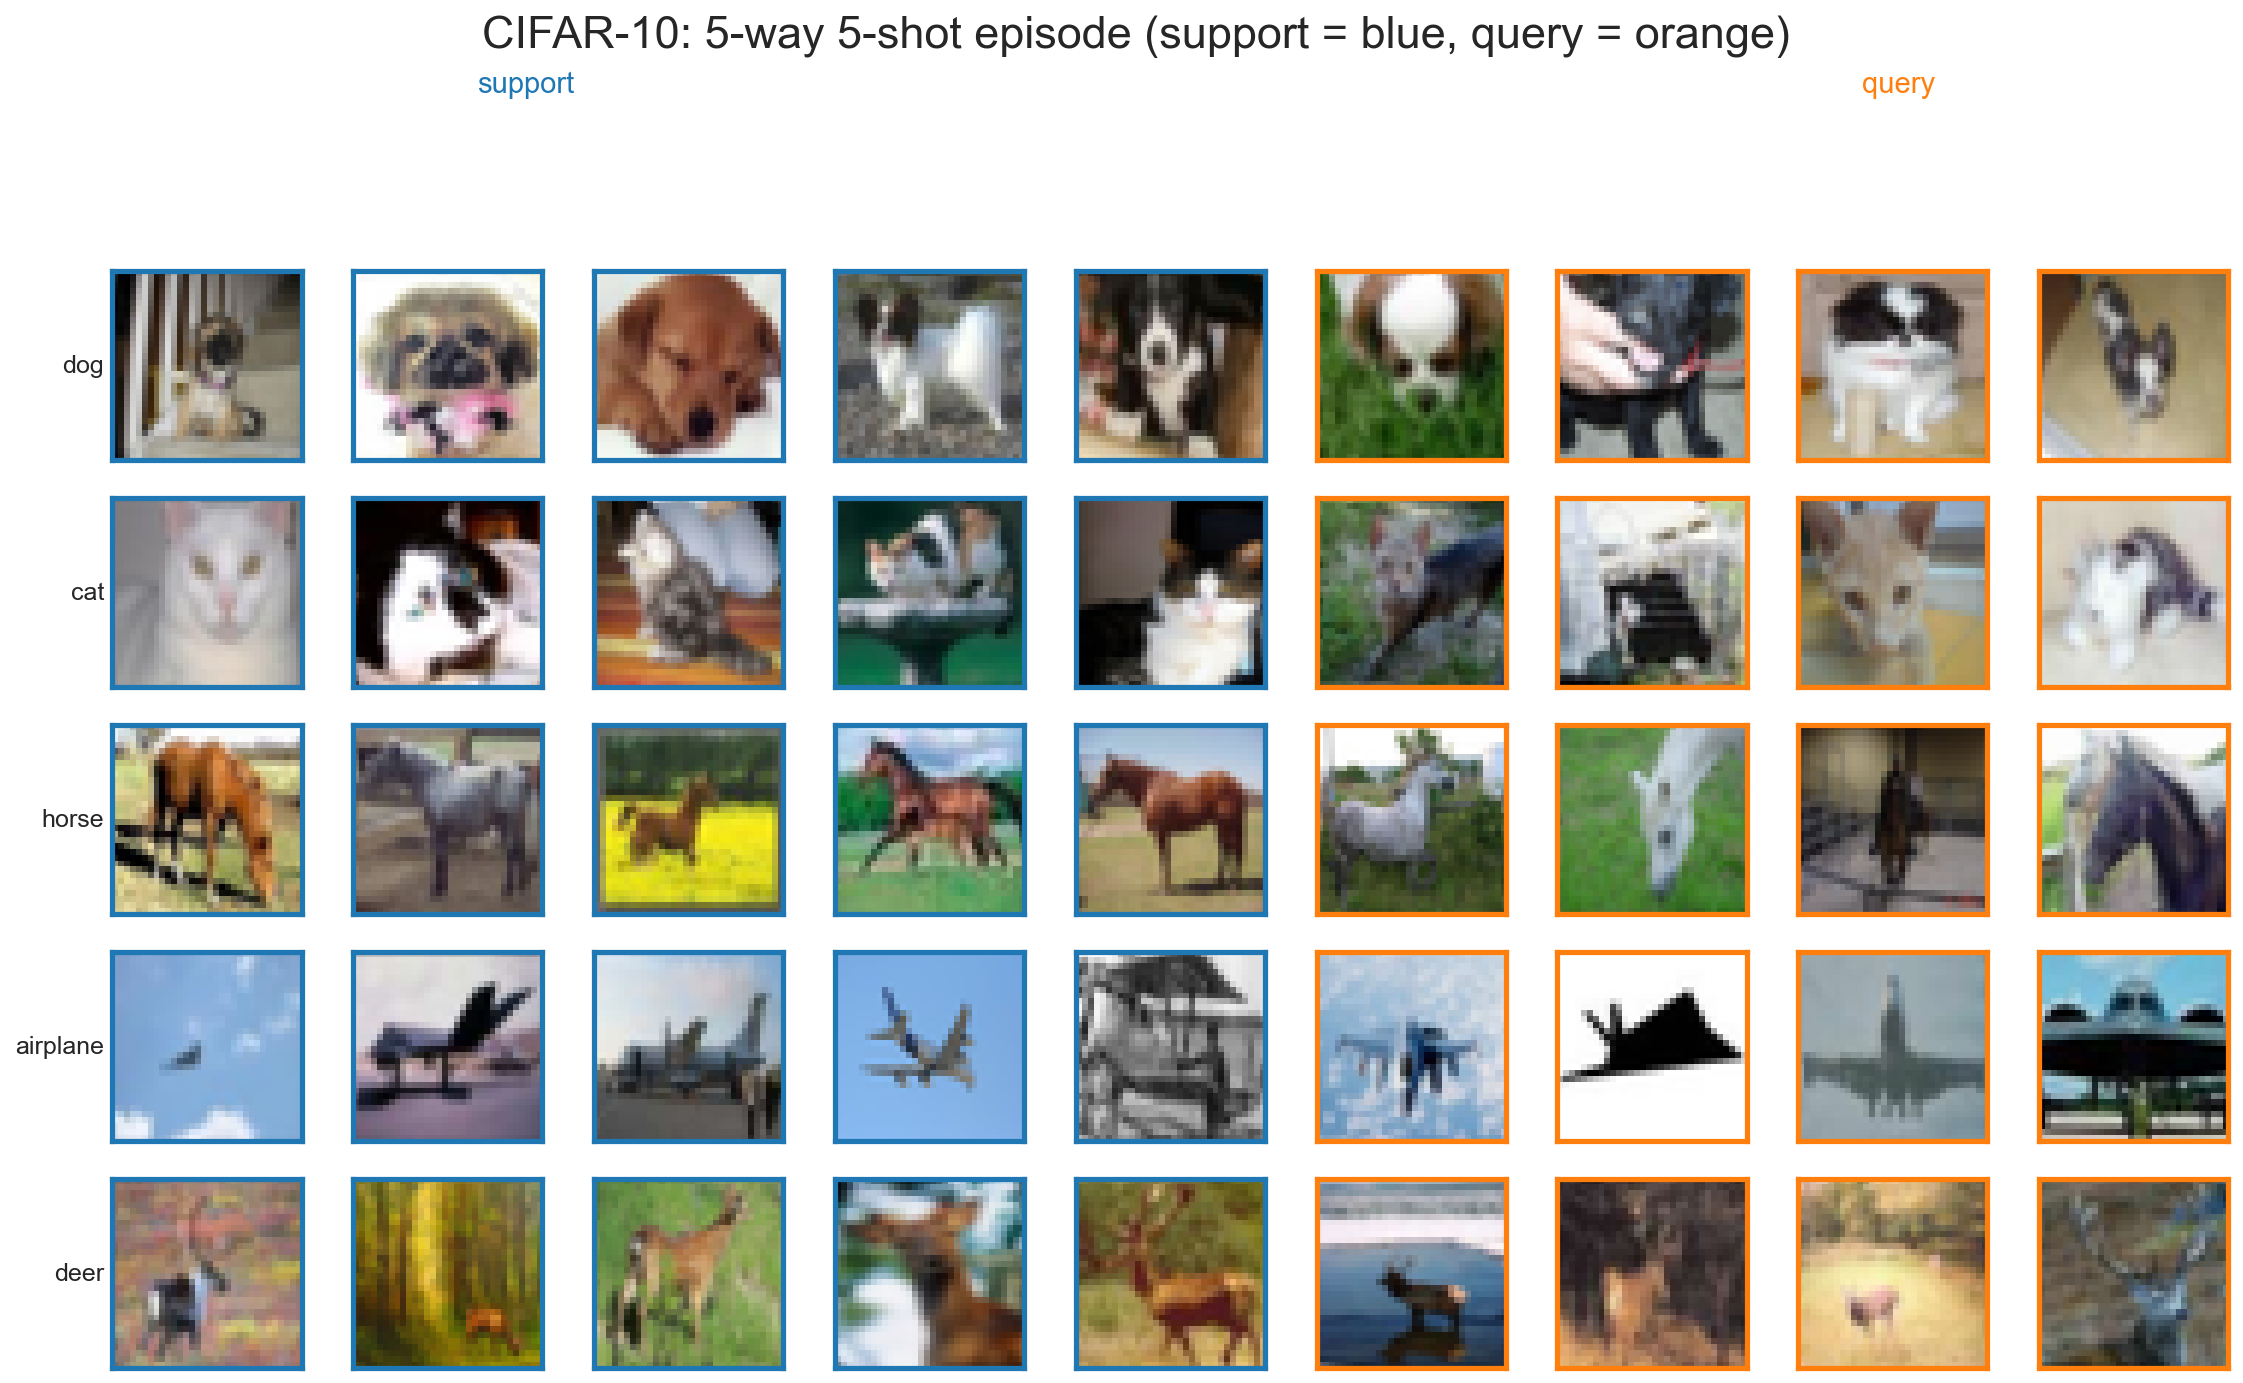

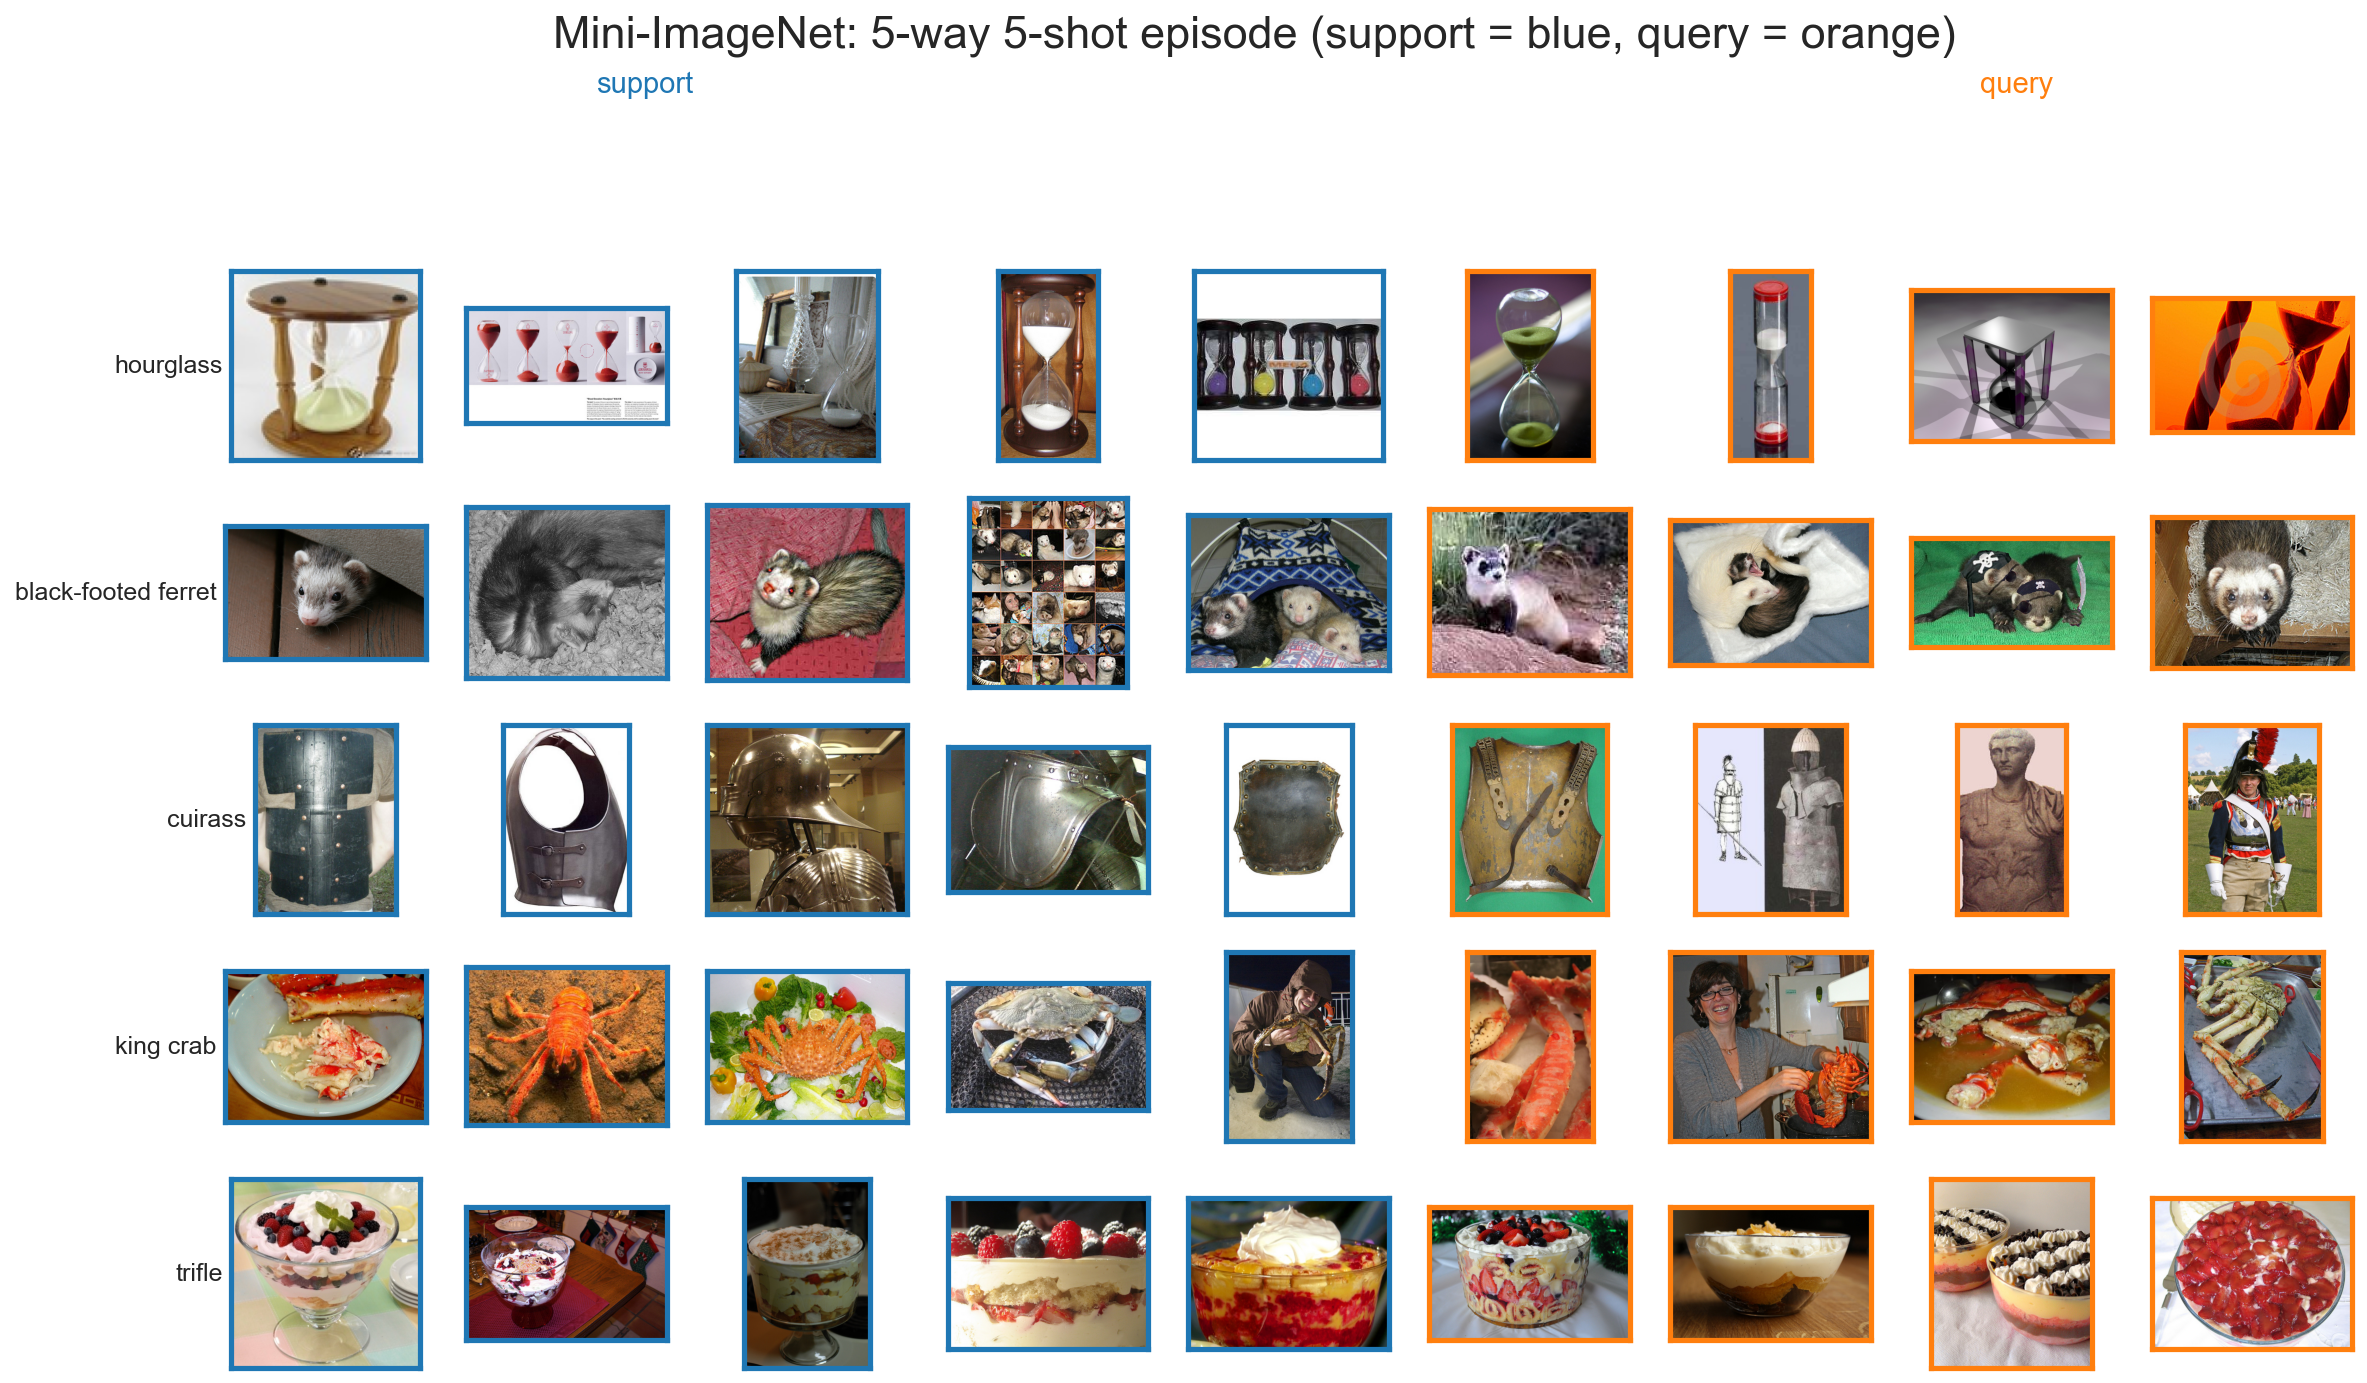

In [2]:
from IPython.display import Image, display

for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"episode_grid_{ds}.png"), width=880))

## 3 · Embedding spaces

t-SNE of the frozen test embeddings per backbone (black star = class prototype). These plots are a **qualitative** visualization — t-SNE distorts distances and neighborhood structure, so they are illustration, not evidence. Their visual class separation is, however, consistent with the quantitative metrics below and with the classification results in §5.

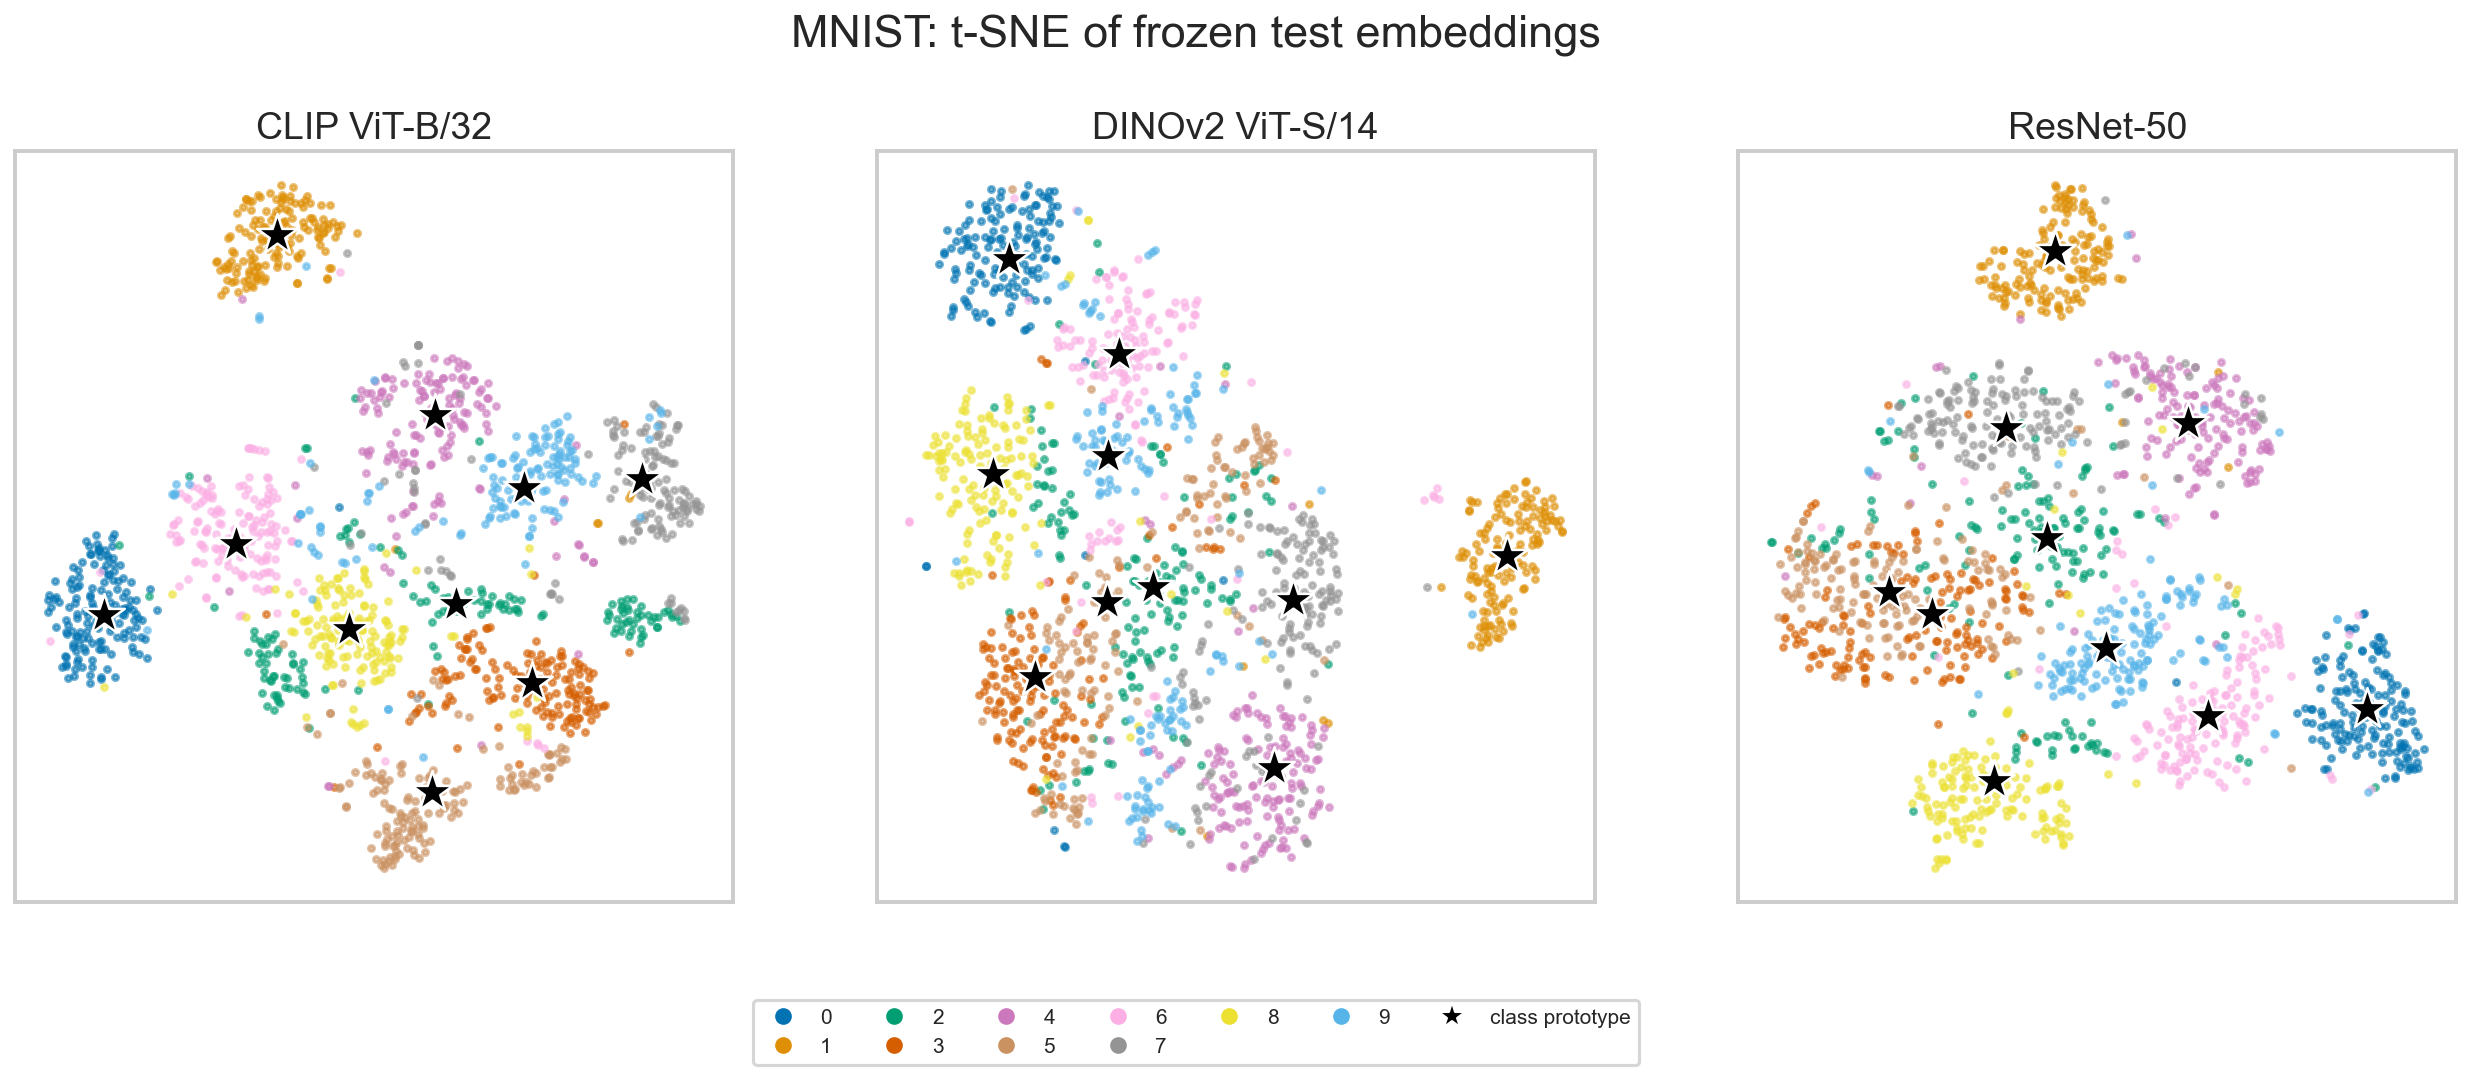

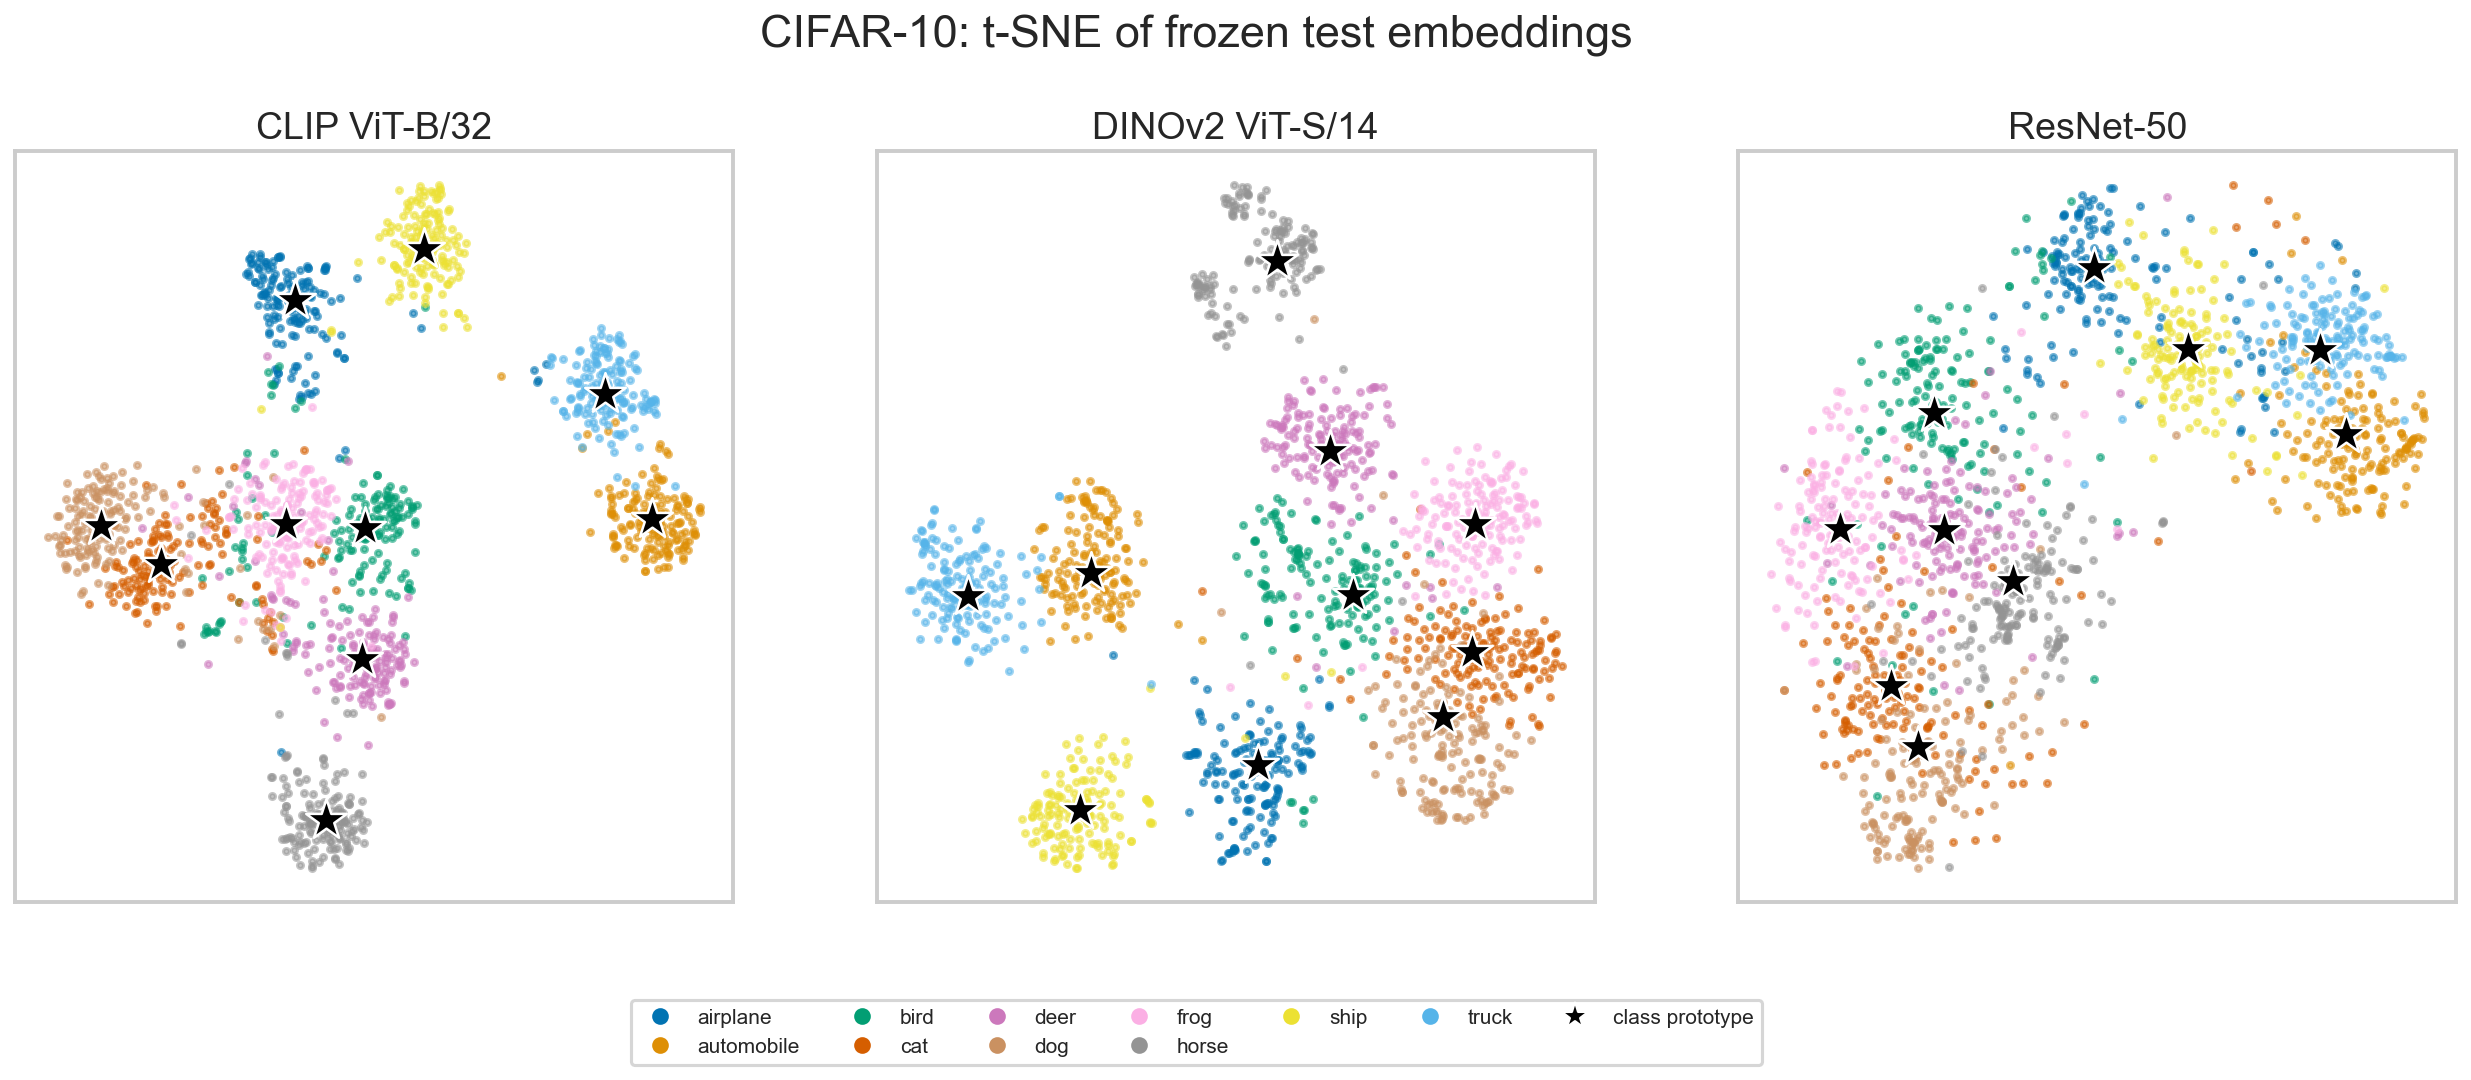

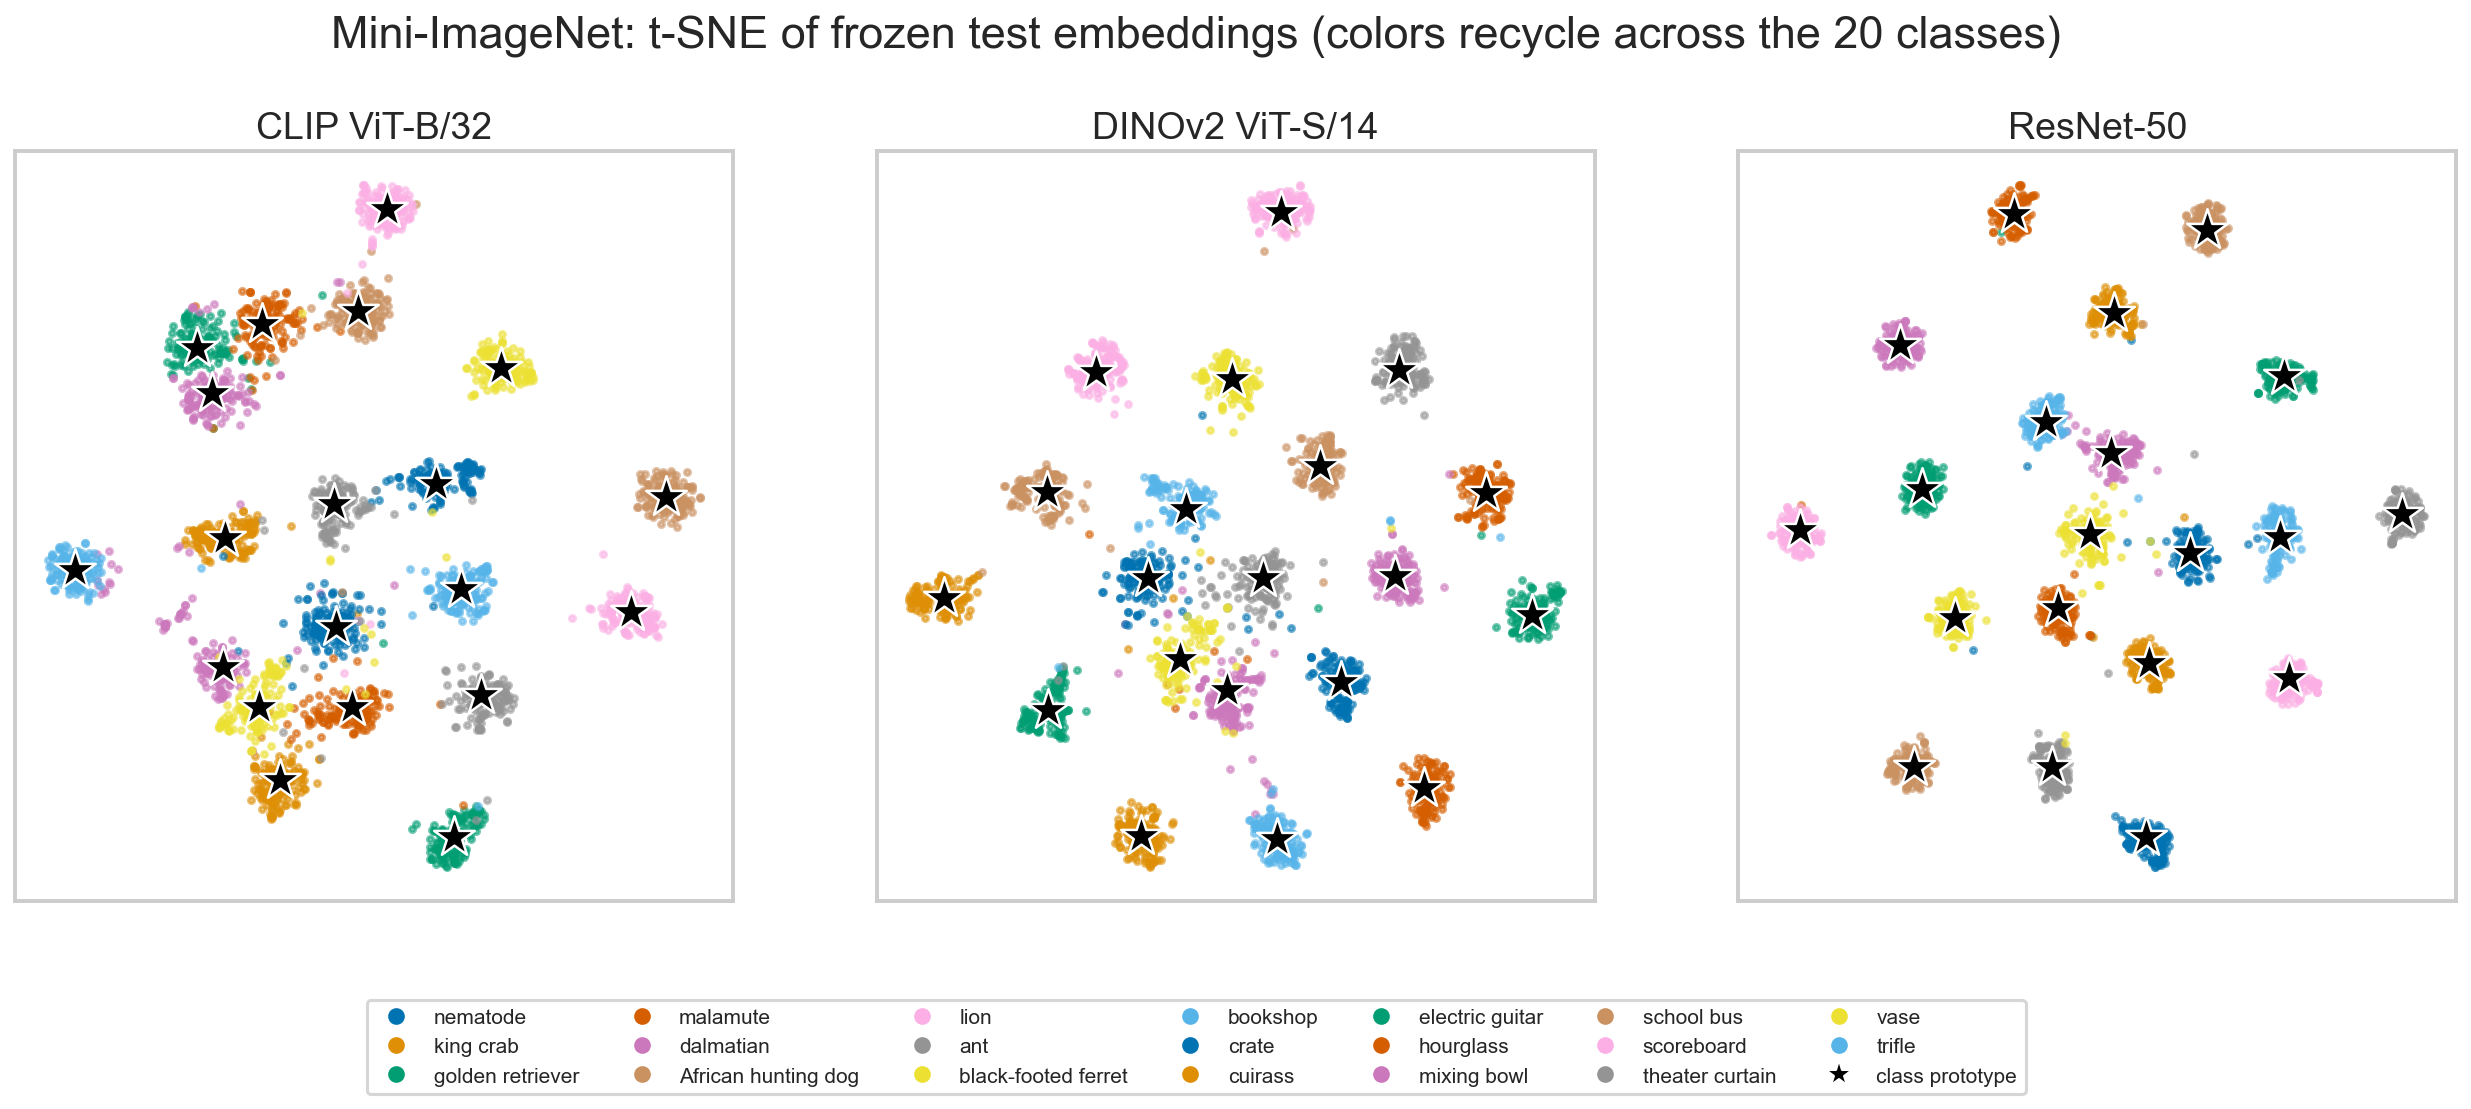

In [3]:
for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"tsne_{ds}.png"), width=980))

**Quantitative embedding quality** (test features, 2000-point subsample, cosine metric): silhouette score and 1-NN accuracy higher = better; within/between-class distance ratio lower = better. The backbone ranking here predicts the prototype-classifier ranking in §5.

In [4]:
eq = pd.read_csv(REPO / "results" / "metrics" / "embedding_quality.csv")
display(eq.pivot(index="backbone", columns="dataset",
                 values=["silhouette", "nn1_acc", "within_between_ratio"]).round(3))

silhouette                     nn1_acc                      \
dataset          cifar10 mini_imagenet mnist cifar10 mini_imagenet mnist   
backbone                                                                   
clip_vitb32         0.17          0.24  0.11    0.89          0.96  0.91   
dinov2_vits14       0.14          0.35  0.12    0.93          0.98  0.88   
resnet50            0.07          0.39  0.11    0.78          0.99  0.90   

              within_between_ratio                      
dataset                    cifar10 mini_imagenet mnist  
backbone                                                
clip_vitb32                   0.66          0.58  0.70  
dinov2_vits14                 0.78          0.60  0.66  
resnet50                      0.78          0.56  0.73

## 4 · Classifiers

All heads share one interface — `predict(Xs, ys, Xq) → scores [B, Q, C]` over cached embeddings — and are pure torch (differentiable), so stage 2/3 can insert a Flow-Matching module upstream without touching evaluation.

**Prototype** — class prototype $c_k = \frac{1}{|S_k|}\sum_{x \in S_k} f(x)$; query scored by cosine similarity (primary) or negative squared Euclidean distance (ablation) to each prototype. No training.

**Linear probe** — `nn.Linear(dim, C)` + `CrossEntropyLoss`, Adam (300 steps, lr 0.01) on the support set only. Episodic evaluation trains all 600 episode heads jointly as a batched tensor `[600, C, dim]` — provably identical to 600 independent heads and 373–455× faster (benchmark below: same seeded init, identical predictions on all 45,000 queries per config; full probe grid 9.1 min → 1.3 s).

**Zero-shot CLIP** — a *semantic reference baseline* based on class names and pretrained image–text alignment: cached text embeddings of dataset-specific prompts (e.g. `'a photo of the number: "{}".'` for MNIST), query scored by image–text cosine similarity. Unlike the two heads above it receives **no support images** — its information source is class names + CLIP pretraining, so it is a reference point rather than an equivalent few-shot method. Single-prompt vs. prompt-ensemble reported separately. In episodic mode only the 5 episode classes are scored.

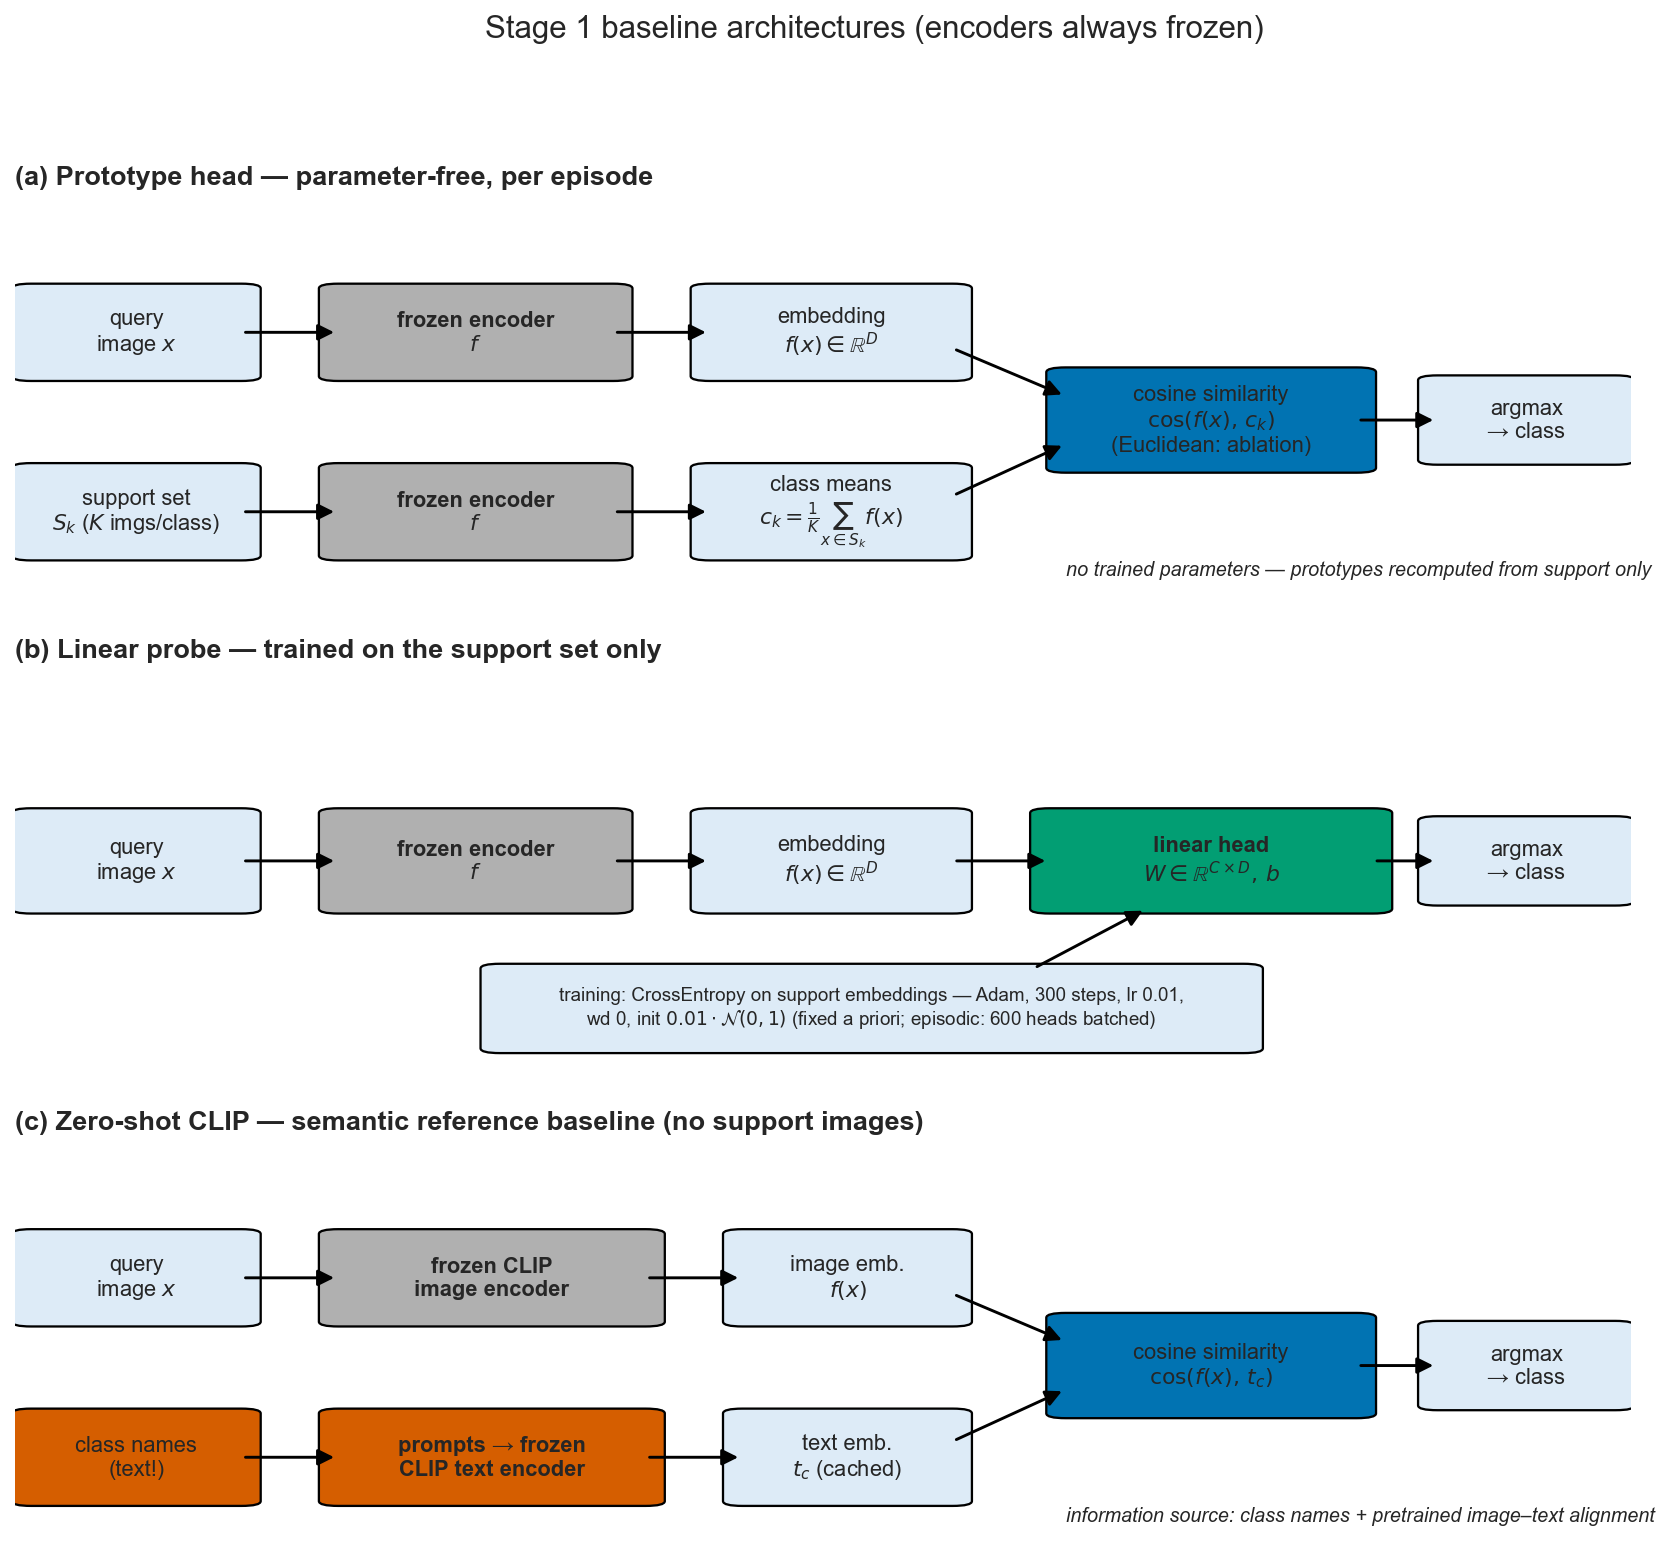

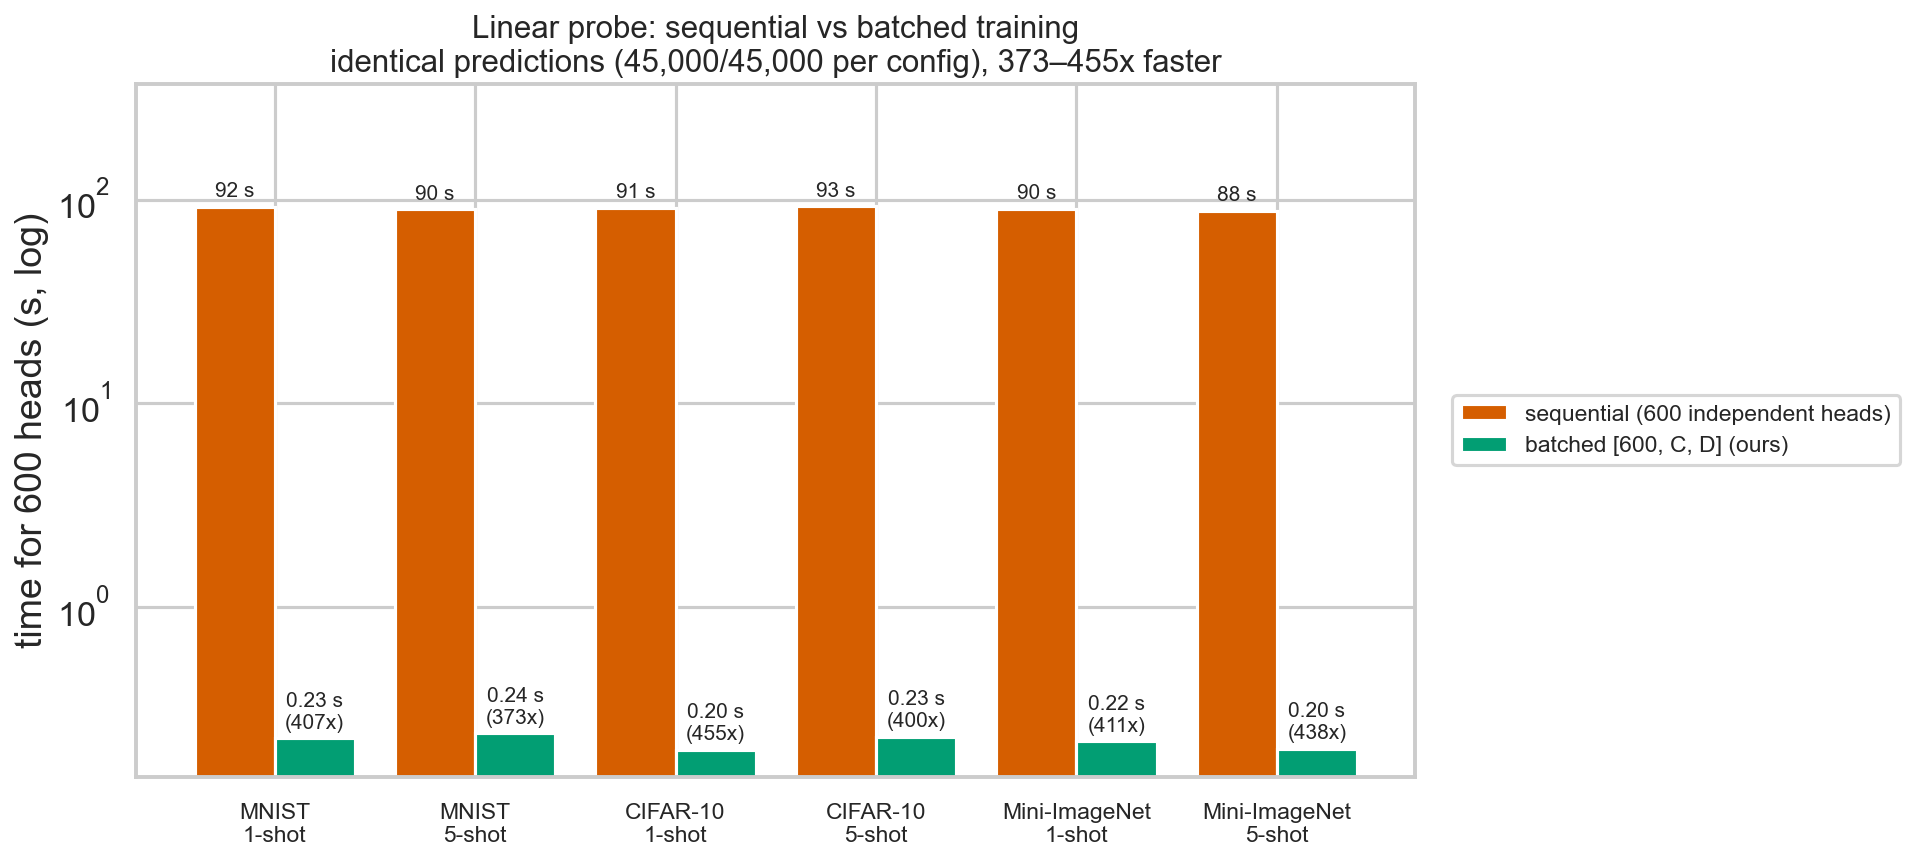

In [5]:
display(Image(str(REPO / "results" / "figures" / "arch_baselines.png"), width=920))
display(Image(str(REPO / "results" / "figures" / "bench_probe.png"), width=880))

## 5 · Results — episodic protocol (mean ± 95% CI, 600 episodes)

In [6]:
import pandas as pd

from src.visualize import method_label

pd.set_option("display.precision", 2)
ep = pd.read_csv(REPO / "results" / "metrics" / "episodic.csv")
ep["accuracy"] = (100 * ep["acc"]).round(2).astype(str) + " ± " + (100 * ep["ci95"]).round(2).astype(str)
ep["method"] = ep["classifier"].map(method_label)
for k in sorted(ep["k_shot"].unique()):
    t = ep[ep["k_shot"] == k].pivot(index="method", columns="dataset", values="accuracy")
    print(f"\n=== 5-way {k}-shot ===")
    display(t)


=== 5-way 1-shot ===


dataset,cifar10,mini_imagenet,mnist
method,,,
"Linear probe, CLIP",76.86 ± 0.8,91.4 ± 0.57,59.96 ± 0.86
"Linear probe, DINOv2",72.76 ± 0.74,92.92 ± 0.53,50.95 ± 0.82
"Linear probe, ResNet-50",61.55 ± 0.74,92.15 ± 0.45,57.51 ± 0.84
"Prototype (cos), CLIP",72.92 ± 0.85,89.15 ± 0.64,56.56 ± 0.87
"Prototype (cos), DINOv2",77.34 ± 0.72,94.42 ± 0.47,56.54 ± 0.92
"Prototype (cos), ResNet-50",62.3 ± 0.76,97.38 ± 0.26,55.96 ± 0.82
"Prototype (eucl), CLIP",74.07 ± 0.82,90.09 ± 0.61,56.64 ± 0.87
"Prototype (eucl), DINOv2",75.3 ± 0.77,94.57 ± 0.47,56.76 ± 0.92
"Prototype (eucl), ResNet-50",57.12 ± 0.8,78.69 ± 1.13,55.79 ± 0.83



=== 5-way 5-shot ===


dataset,cifar10,mini_imagenet,mnist
method,,,
"Linear probe, CLIP",90.82 ± 0.37,98.26 ± 0.16,86.6 ± 0.44
"Linear probe, DINOv2",90.68 ± 0.39,98.15 ± 0.17,80.18 ± 0.6
"Linear probe, ResNet-50",80.33 ± 0.5,98.18 ± 0.16,83.3 ± 0.56
"Prototype (cos), CLIP",89.16 ± 0.42,97.7 ± 0.2,78.01 ± 0.6
"Prototype (cos), DINOv2",91.95 ± 0.37,98.56 ± 0.15,75.61 ± 0.67
"Prototype (cos), ResNet-50",81.68 ± 0.48,99.51 ± 0.08,76.86 ± 0.7
"Prototype (eucl), CLIP",89.23 ± 0.42,97.66 ± 0.2,77.93 ± 0.6
"Prototype (eucl), DINOv2",91.91 ± 0.36,98.01 ± 0.17,75.6 ± 0.67
"Prototype (eucl), ResNet-50",81.21 ± 0.48,99.29 ± 0.1,76.87 ± 0.69


**How to read the next two charts:** zero-shot CLIP wins on both natural-image datasets but is the *worst* head on MNIST — the one dataset far from its training distribution. In the backbone chart, ResNet-50's Mini-ImageNet bar is inflated by ImageNet-label overlap (§6), not few-shot skill.

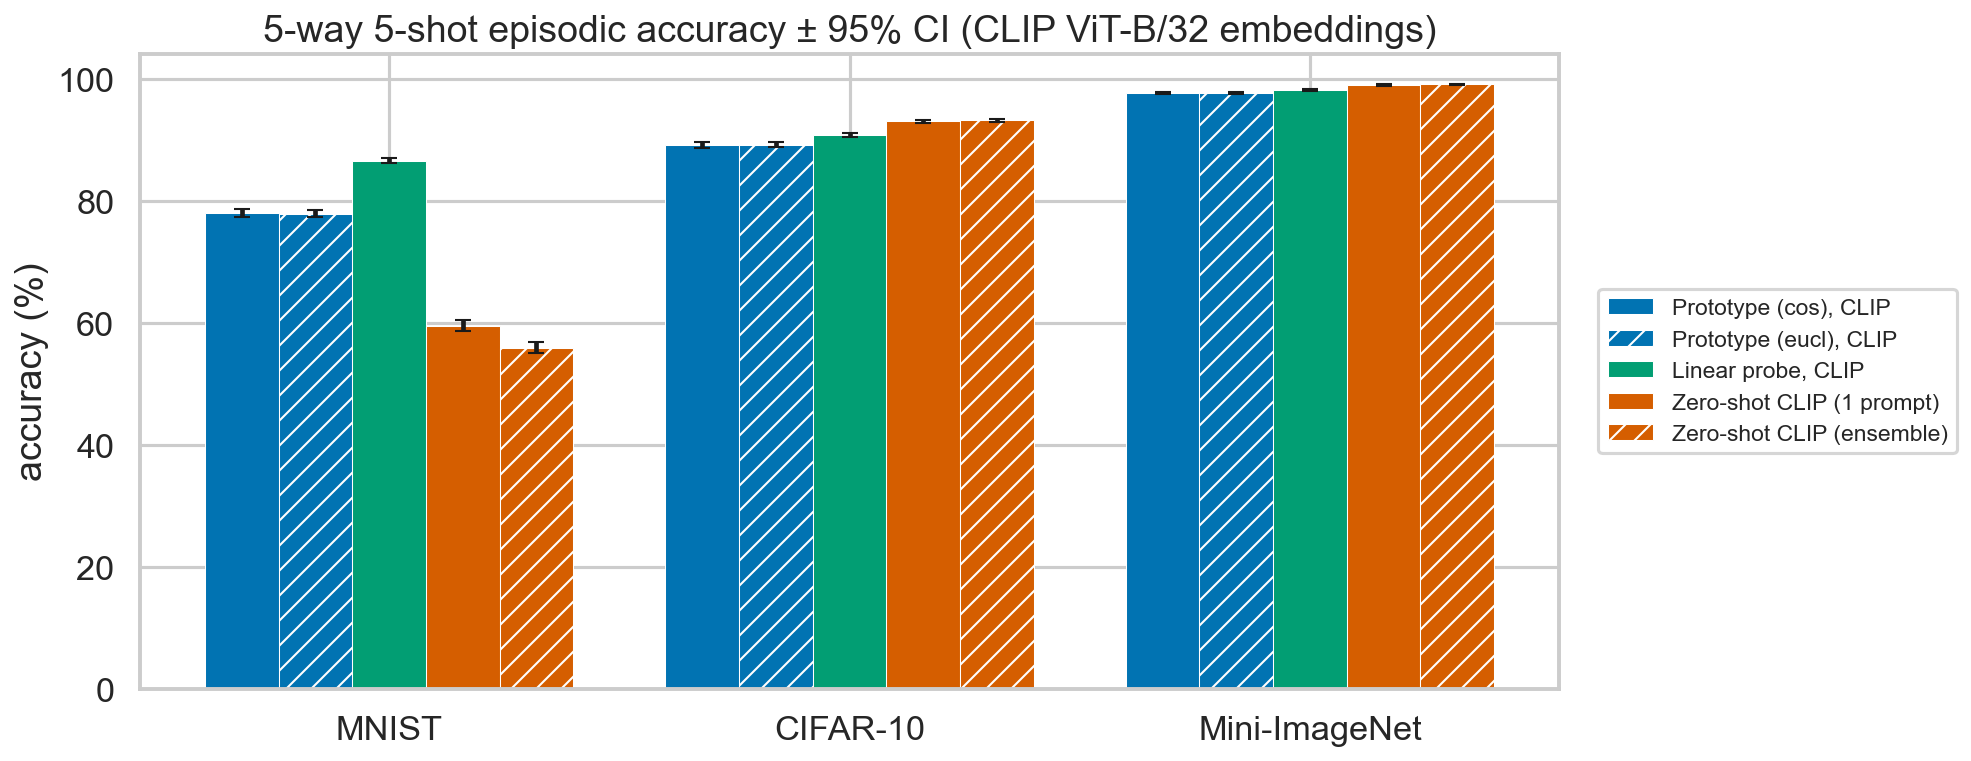

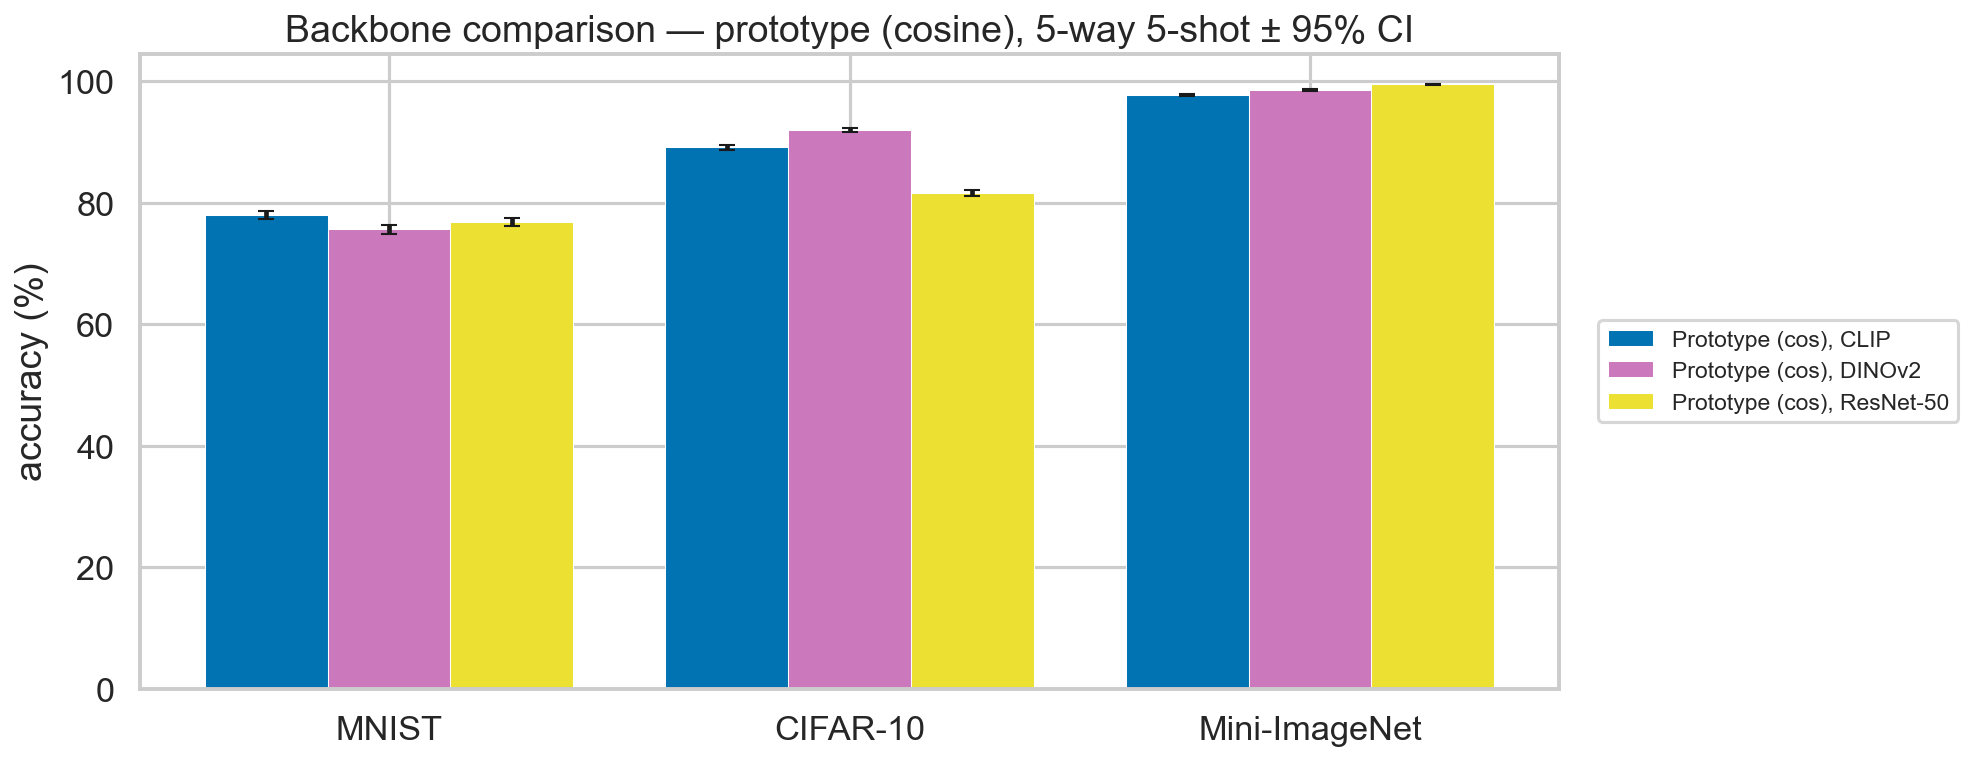

In [7]:
display(Image(str(REPO / "results" / "figures" / "bars_episodic_5shot.png"), width=880))
display(Image(str(REPO / "results" / "figures" / "bars_backbones.png"), width=880))

**Accuracy vs. shots:** compare each backbone's linear probe (diamond markers) with its own prototype heads (circles/squares, same color). On CLIP the probe leads everywhere; on DINOv2 the prototype leads at K=1 — the probe-vs-prototype ranking is encoder-dependent (§6–7).

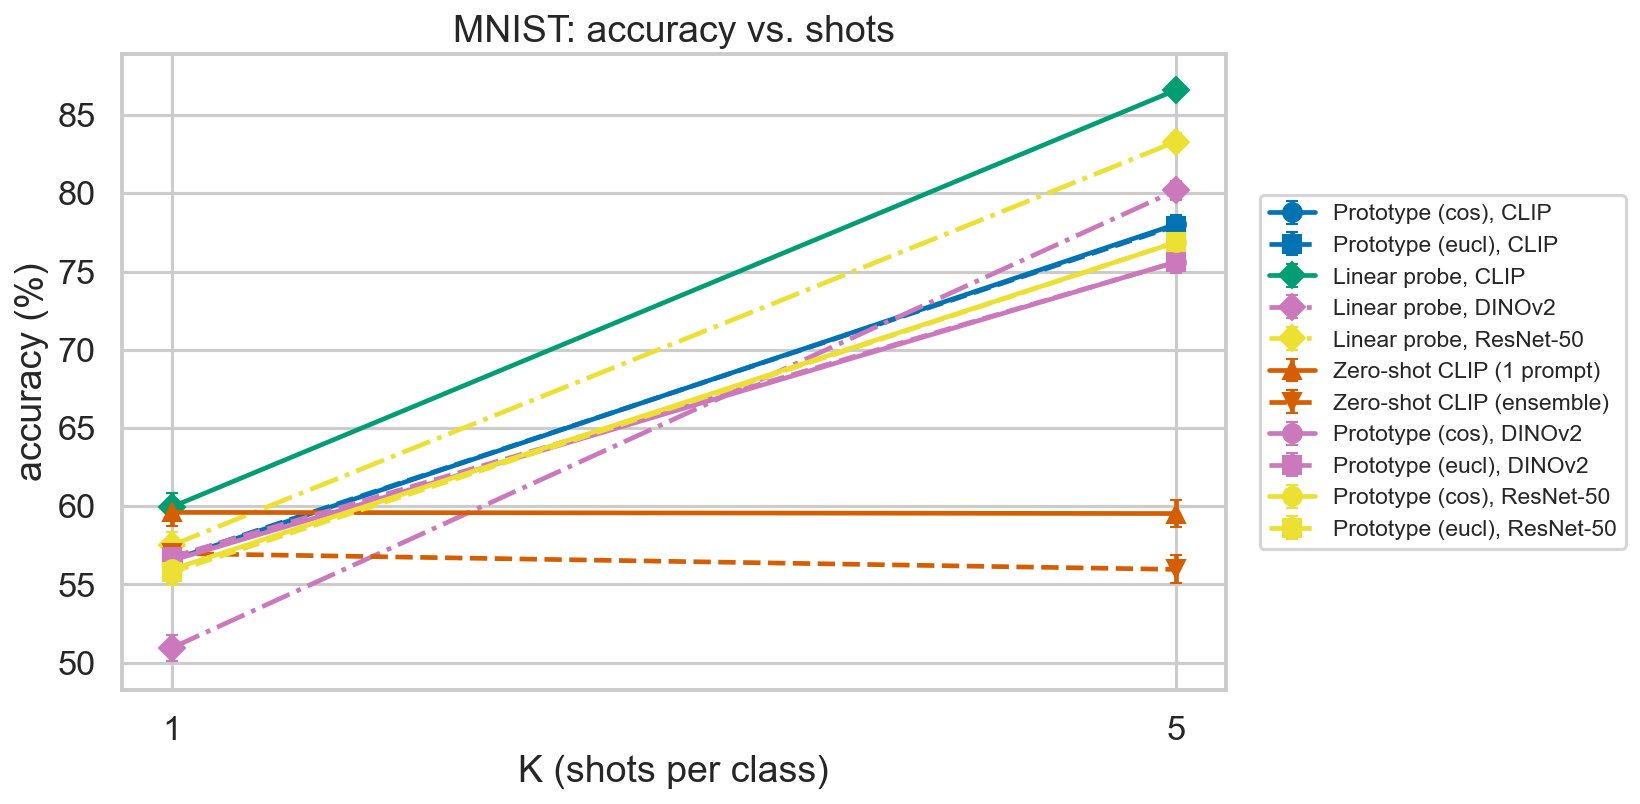

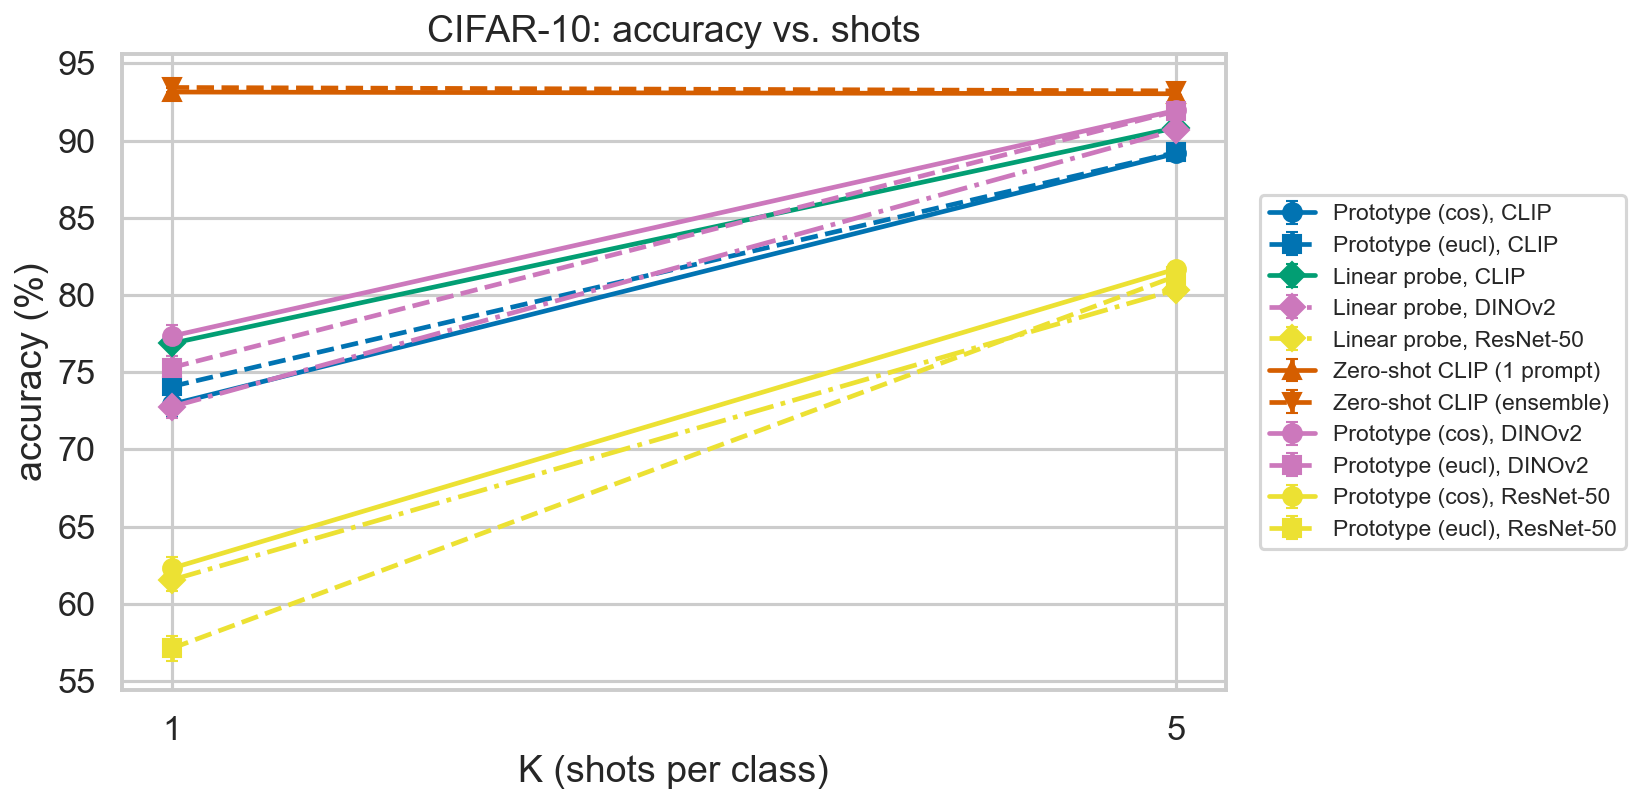

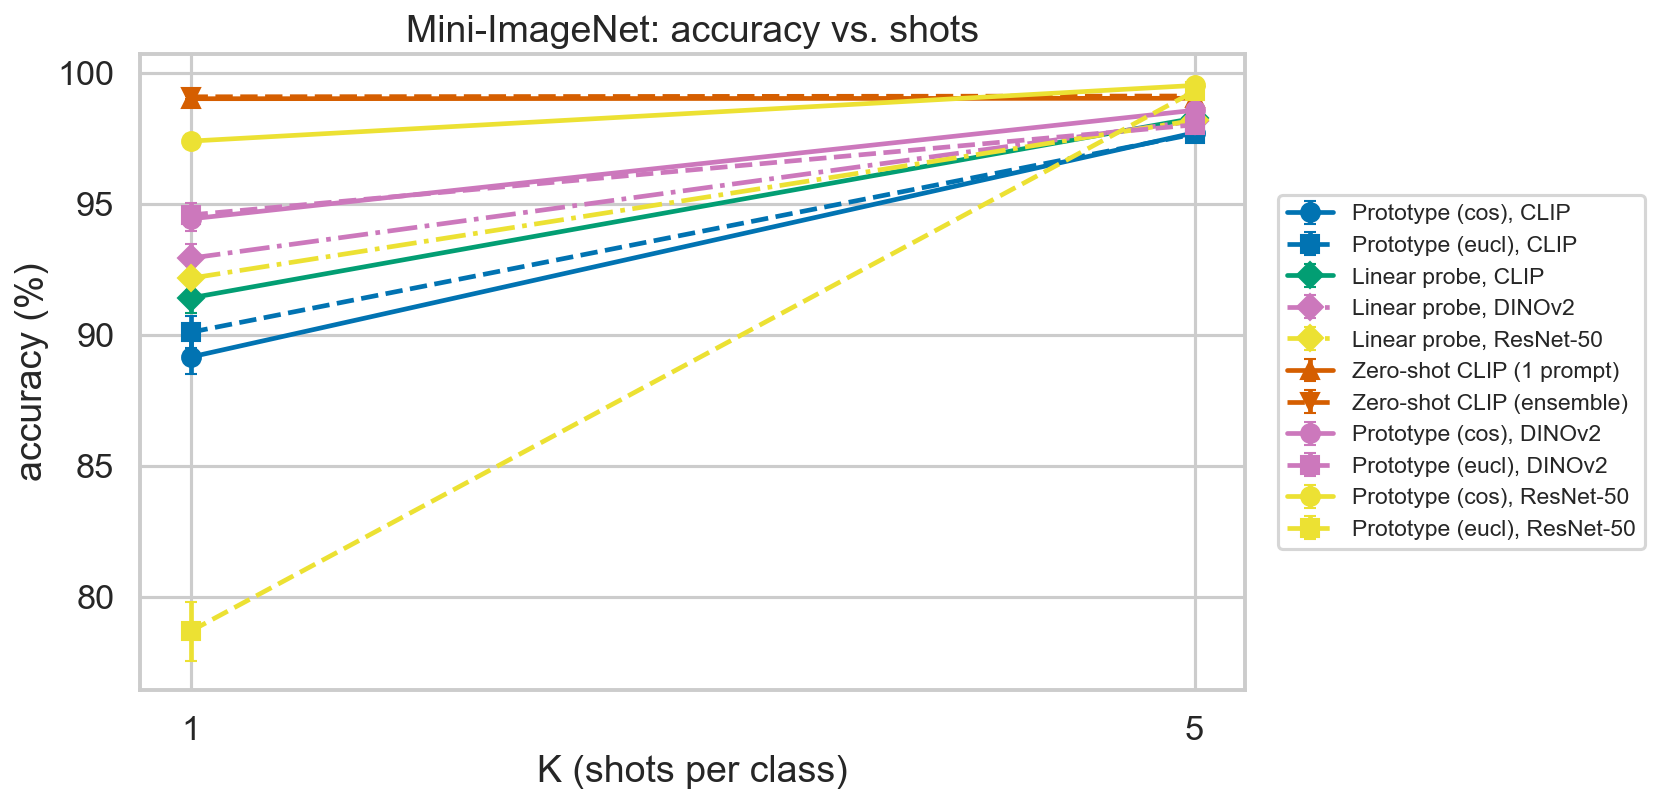

In [8]:
for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_k_episodic_{ds}.png"), width=820))

## 5b · Results — simple all-classes protocol (mean ± std, 10 seeds)


=== mnist (all classes, full test set; k_shot=0 = zero-shot, deterministic -> no std) ===


k_shot,0,1,5,10
method,,,,
"Linear probe, CLIP",NaN,49.95 ± 5.47,79.7 ± 1.41,88.62 ± 1.41
"Linear probe, DINOv2",NaN,41.2 ± 3.04,72.38 ± 3.08,80.0 ± 1.25
"Linear probe, ResNet-50",NaN,44.67 ± 5.41,74.43 ± 3.84,82.69 ± 1.98
"Prototype (cos), CLIP",NaN,44.31 ± 5.75,66.53 ± 2.7,73.32 ± 1.88
"Prototype (cos), DINOv2",NaN,44.17 ± 4.16,64.1 ± 4.23,70.08 ± 1.57
"Prototype (cos), ResNet-50",NaN,43.16 ± 6.06,64.69 ± 4.73,72.68 ± 3.01
"Prototype (eucl), CLIP",NaN,44.6 ± 5.66,66.37 ± 2.72,73.22 ± 1.95
"Prototype (eucl), DINOv2",NaN,44.52 ± 4.14,64.1 ± 4.19,70.03 ± 1.62
"Prototype (eucl), ResNet-50",NaN,42.96 ± 5.88,64.84 ± 4.63,72.7 ± 3.01



=== cifar10 (all classes, full test set; k_shot=0 = zero-shot, deterministic -> no std) ===


k_shot,0,1,5,10
method,,,,
"Linear probe, CLIP",NaN,66.69 ± 4.59,86.37 ± 1.36,88.93 ± 0.79
"Linear probe, DINOv2",NaN,60.3 ± 4.7,85.68 ± 1.68,89.69 ± 0.97
"Linear probe, ResNet-50",NaN,45.66 ± 2.09,68.2 ± 2.24,75.32 ± 1.79
"Prototype (cos), CLIP",NaN,61.07 ± 6.01,83.05 ± 1.84,86.26 ± 1.8
"Prototype (cos), DINOv2",NaN,65.36 ± 3.95,87.48 ± 1.62,90.25 ± 0.76
"Prototype (cos), ResNet-50",NaN,48.59 ± 3.03,69.28 ± 2.26,75.25 ± 2.16
"Prototype (eucl), CLIP",NaN,62.36 ± 5.48,83.02 ± 1.88,86.25 ± 1.72
"Prototype (eucl), DINOv2",NaN,62.53 ± 4.22,87.69 ± 1.51,90.22 ± 0.88
"Prototype (eucl), ResNet-50",NaN,42.91 ± 3.41,68.83 ± 2.31,75.07 ± 2.42


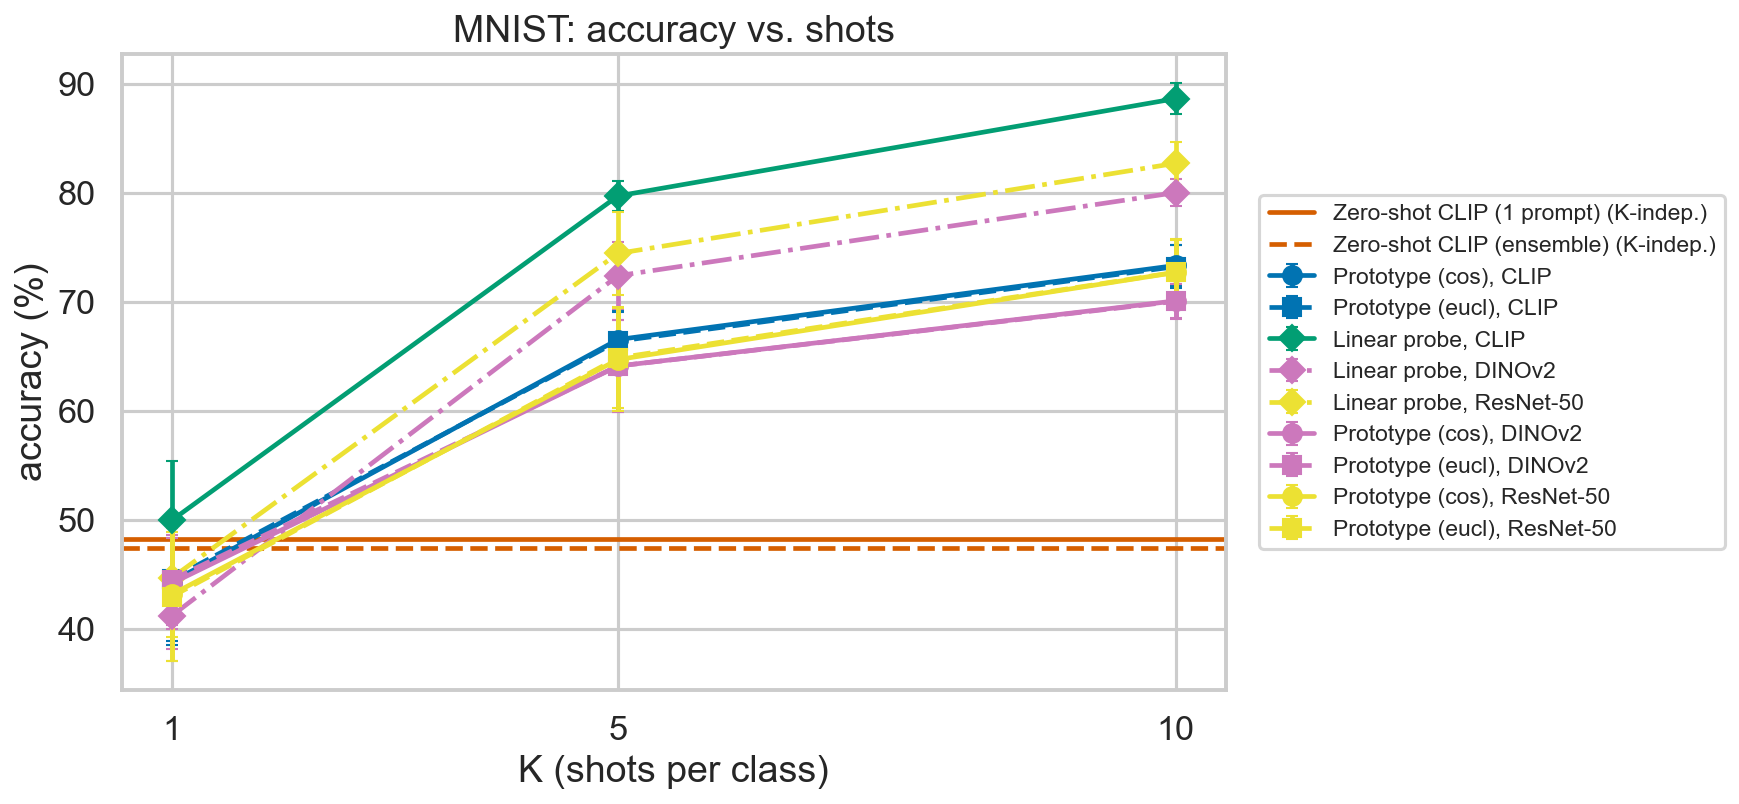

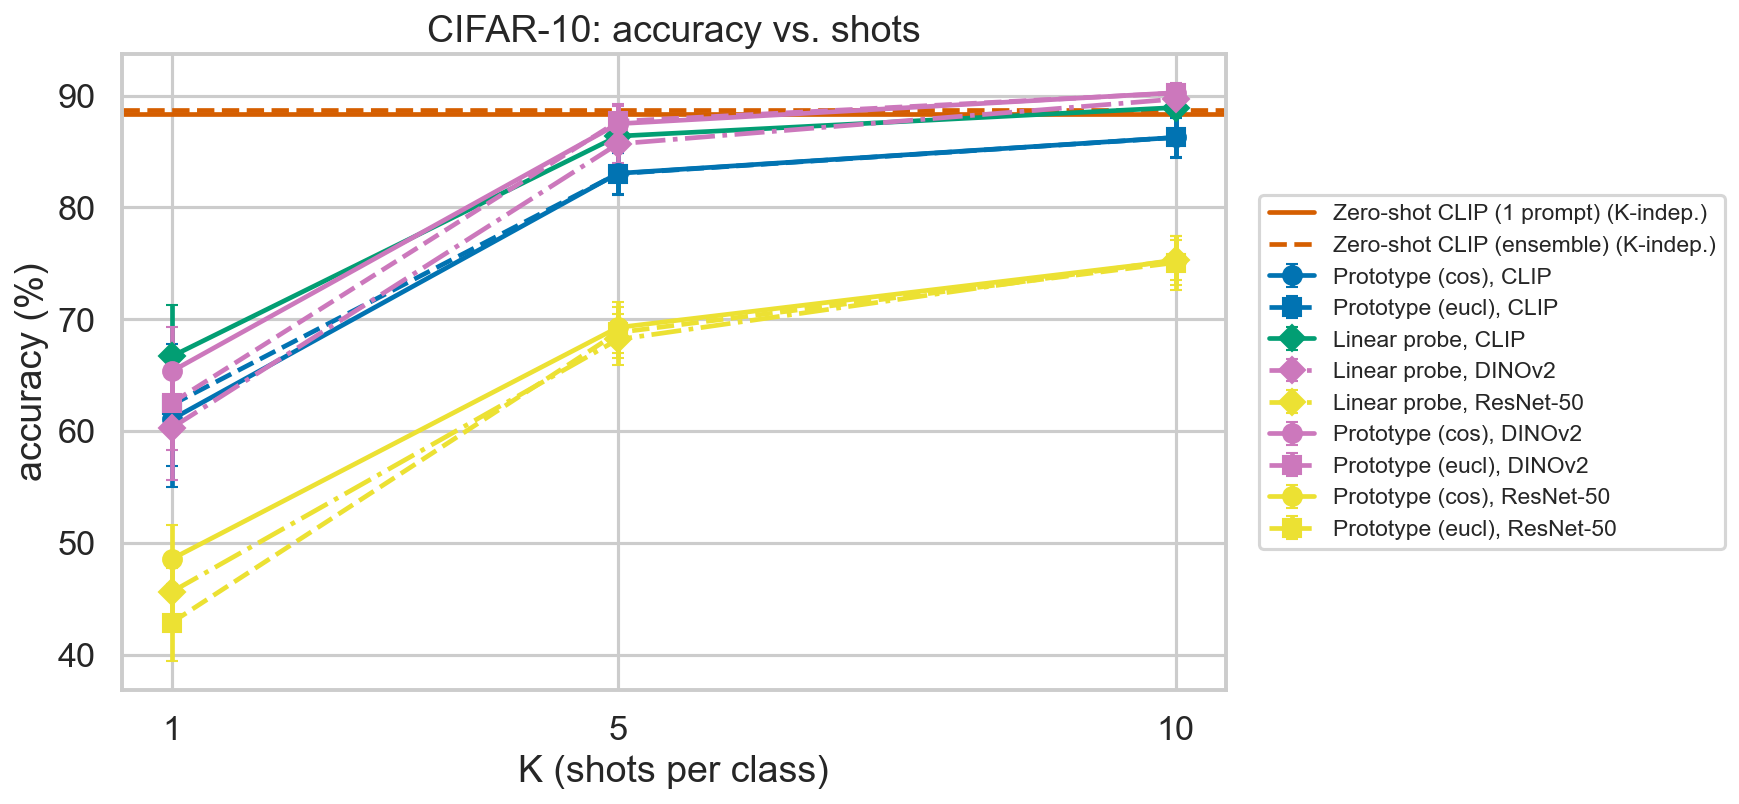

In [9]:
si = pd.read_csv(REPO / "results" / "metrics" / "simple.csv")
# Zero-shot CLIP is deterministic (no support sampling), so no std is reported
# for it — displaying "± 0.00" would misleadingly suggest a seed sweep.
si["accuracy"] = (100 * si["acc"]).round(2).astype(str) + " ± " + (100 * si["std"]).round(2).astype(str)
si.loc[si["k_shot"] == 0, "accuracy"] = (100 * si.loc[si["k_shot"] == 0, "acc"]).round(2).astype(str)
si["method"] = si["classifier"].map(method_label)
for ds in ("mnist", "cifar10"):
    t = si[si["dataset"] == ds].pivot(index="method", columns="k_shot", values="accuracy")
    print(f"\n=== {ds} (all classes, full test set; k_shot=0 = zero-shot, "
          f"deterministic -> no std) ===")
    display(t)
for ds in ("mnist", "cifar10"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_k_simple_{ds}.png"), width=820))

### Qualitative results

The confusion matrices show *where* the prototype head fails: 2/7/9 on MNIST, the cat↔dog and bird↔deer pairs on CIFAR-10. The zero-shot panels show the *least confident* CLIP predictions — even the hardest cases are two-way ambiguities. The failure galleries show the most confident misclassification per (true, predicted) pair.

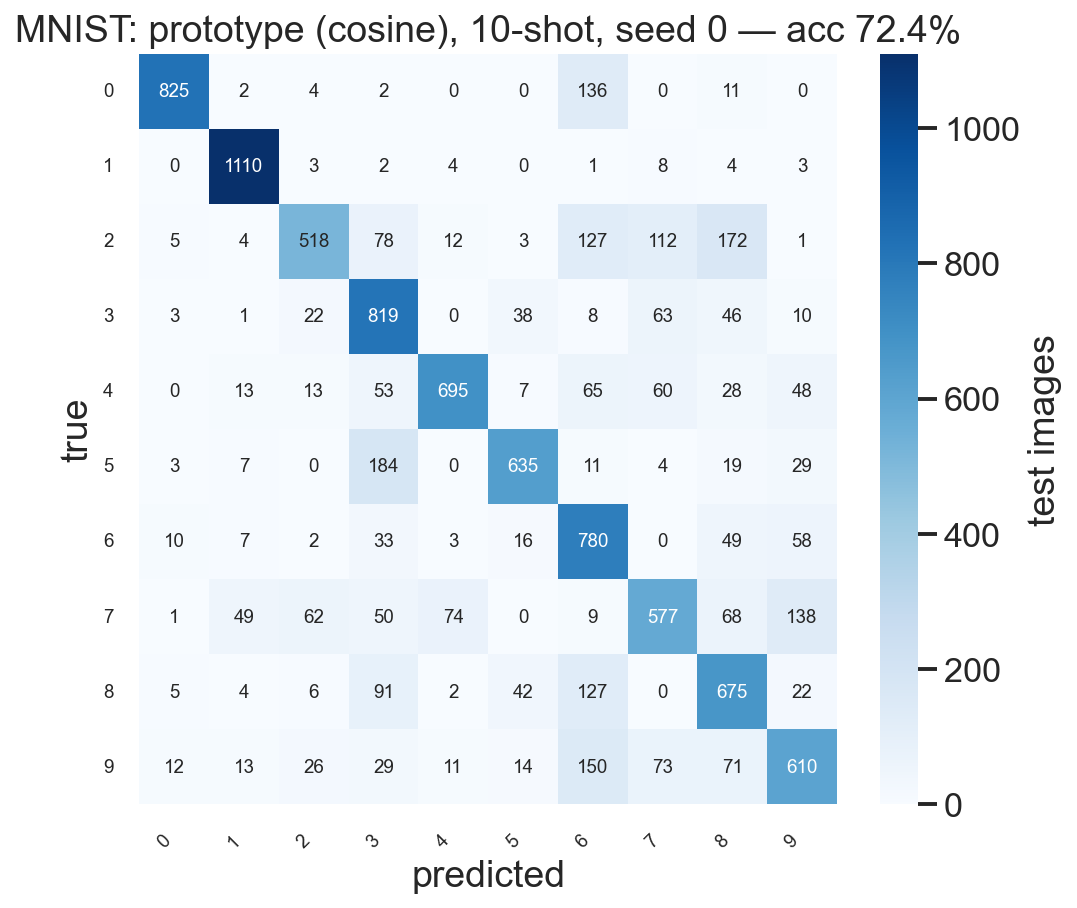

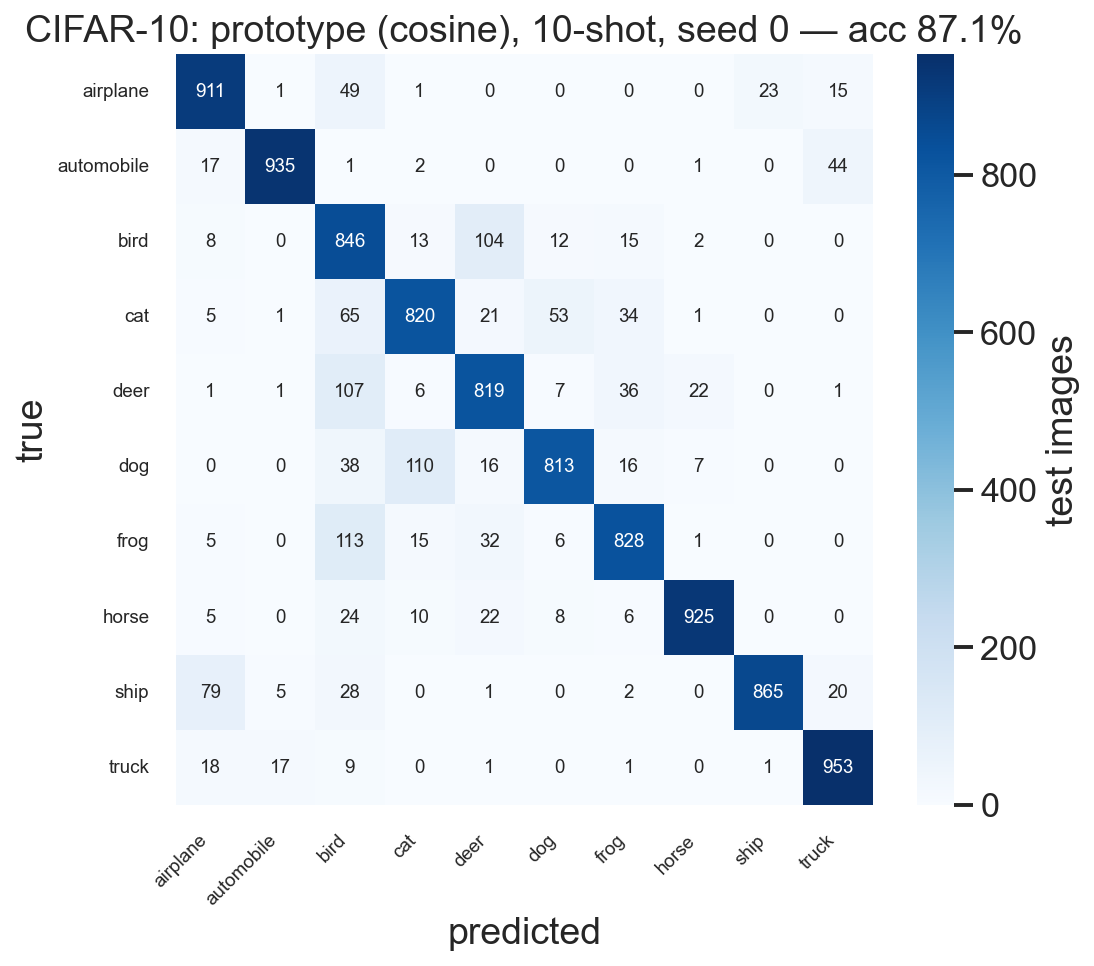

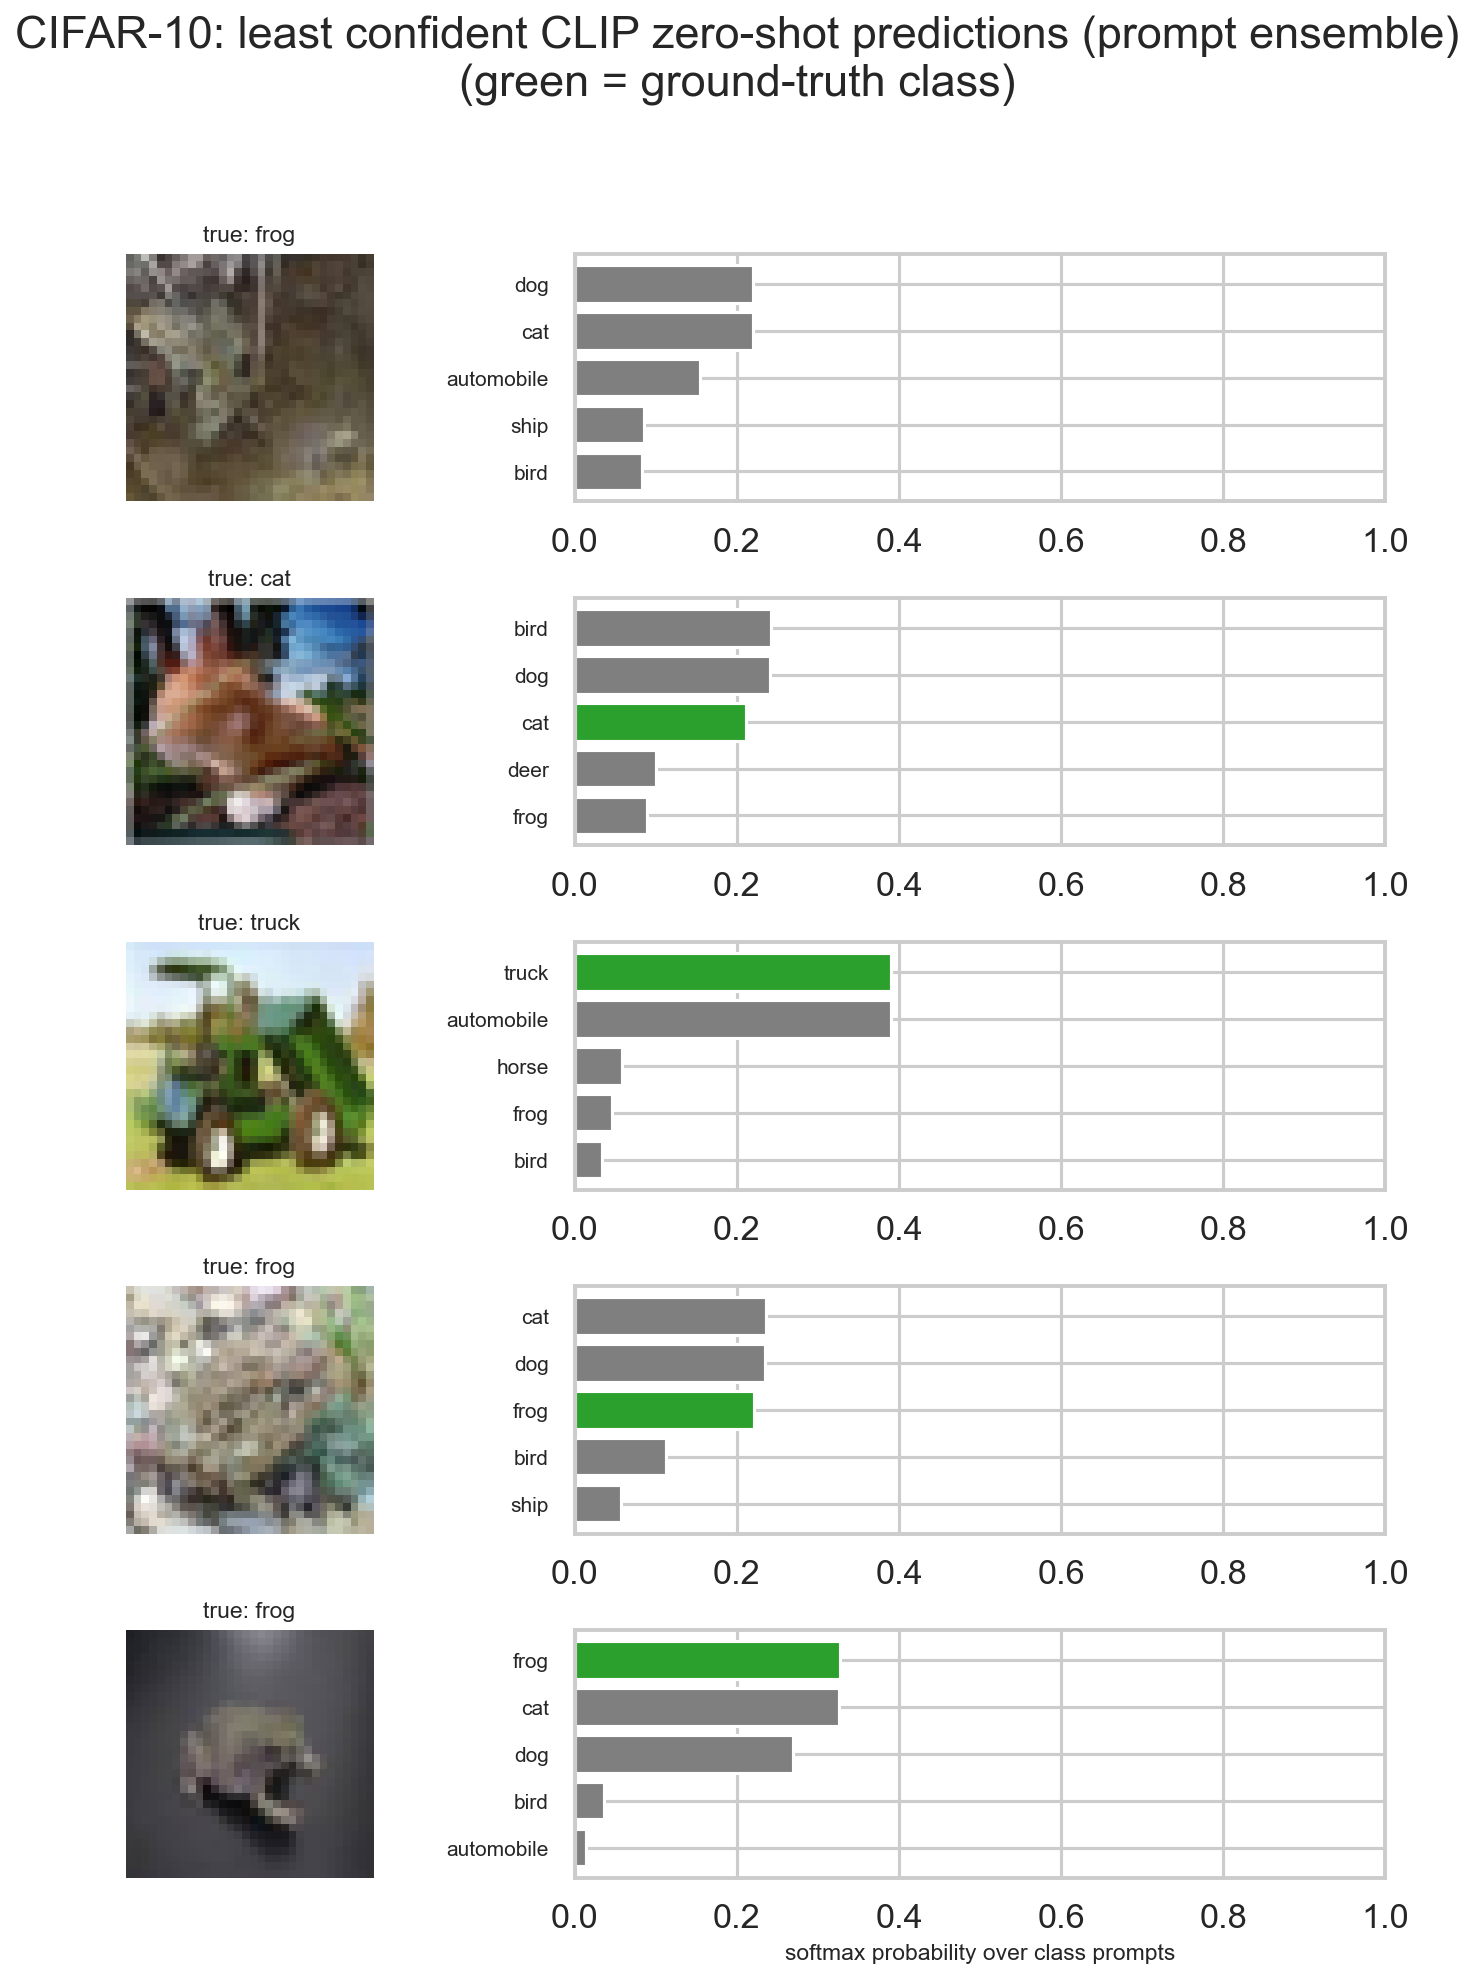

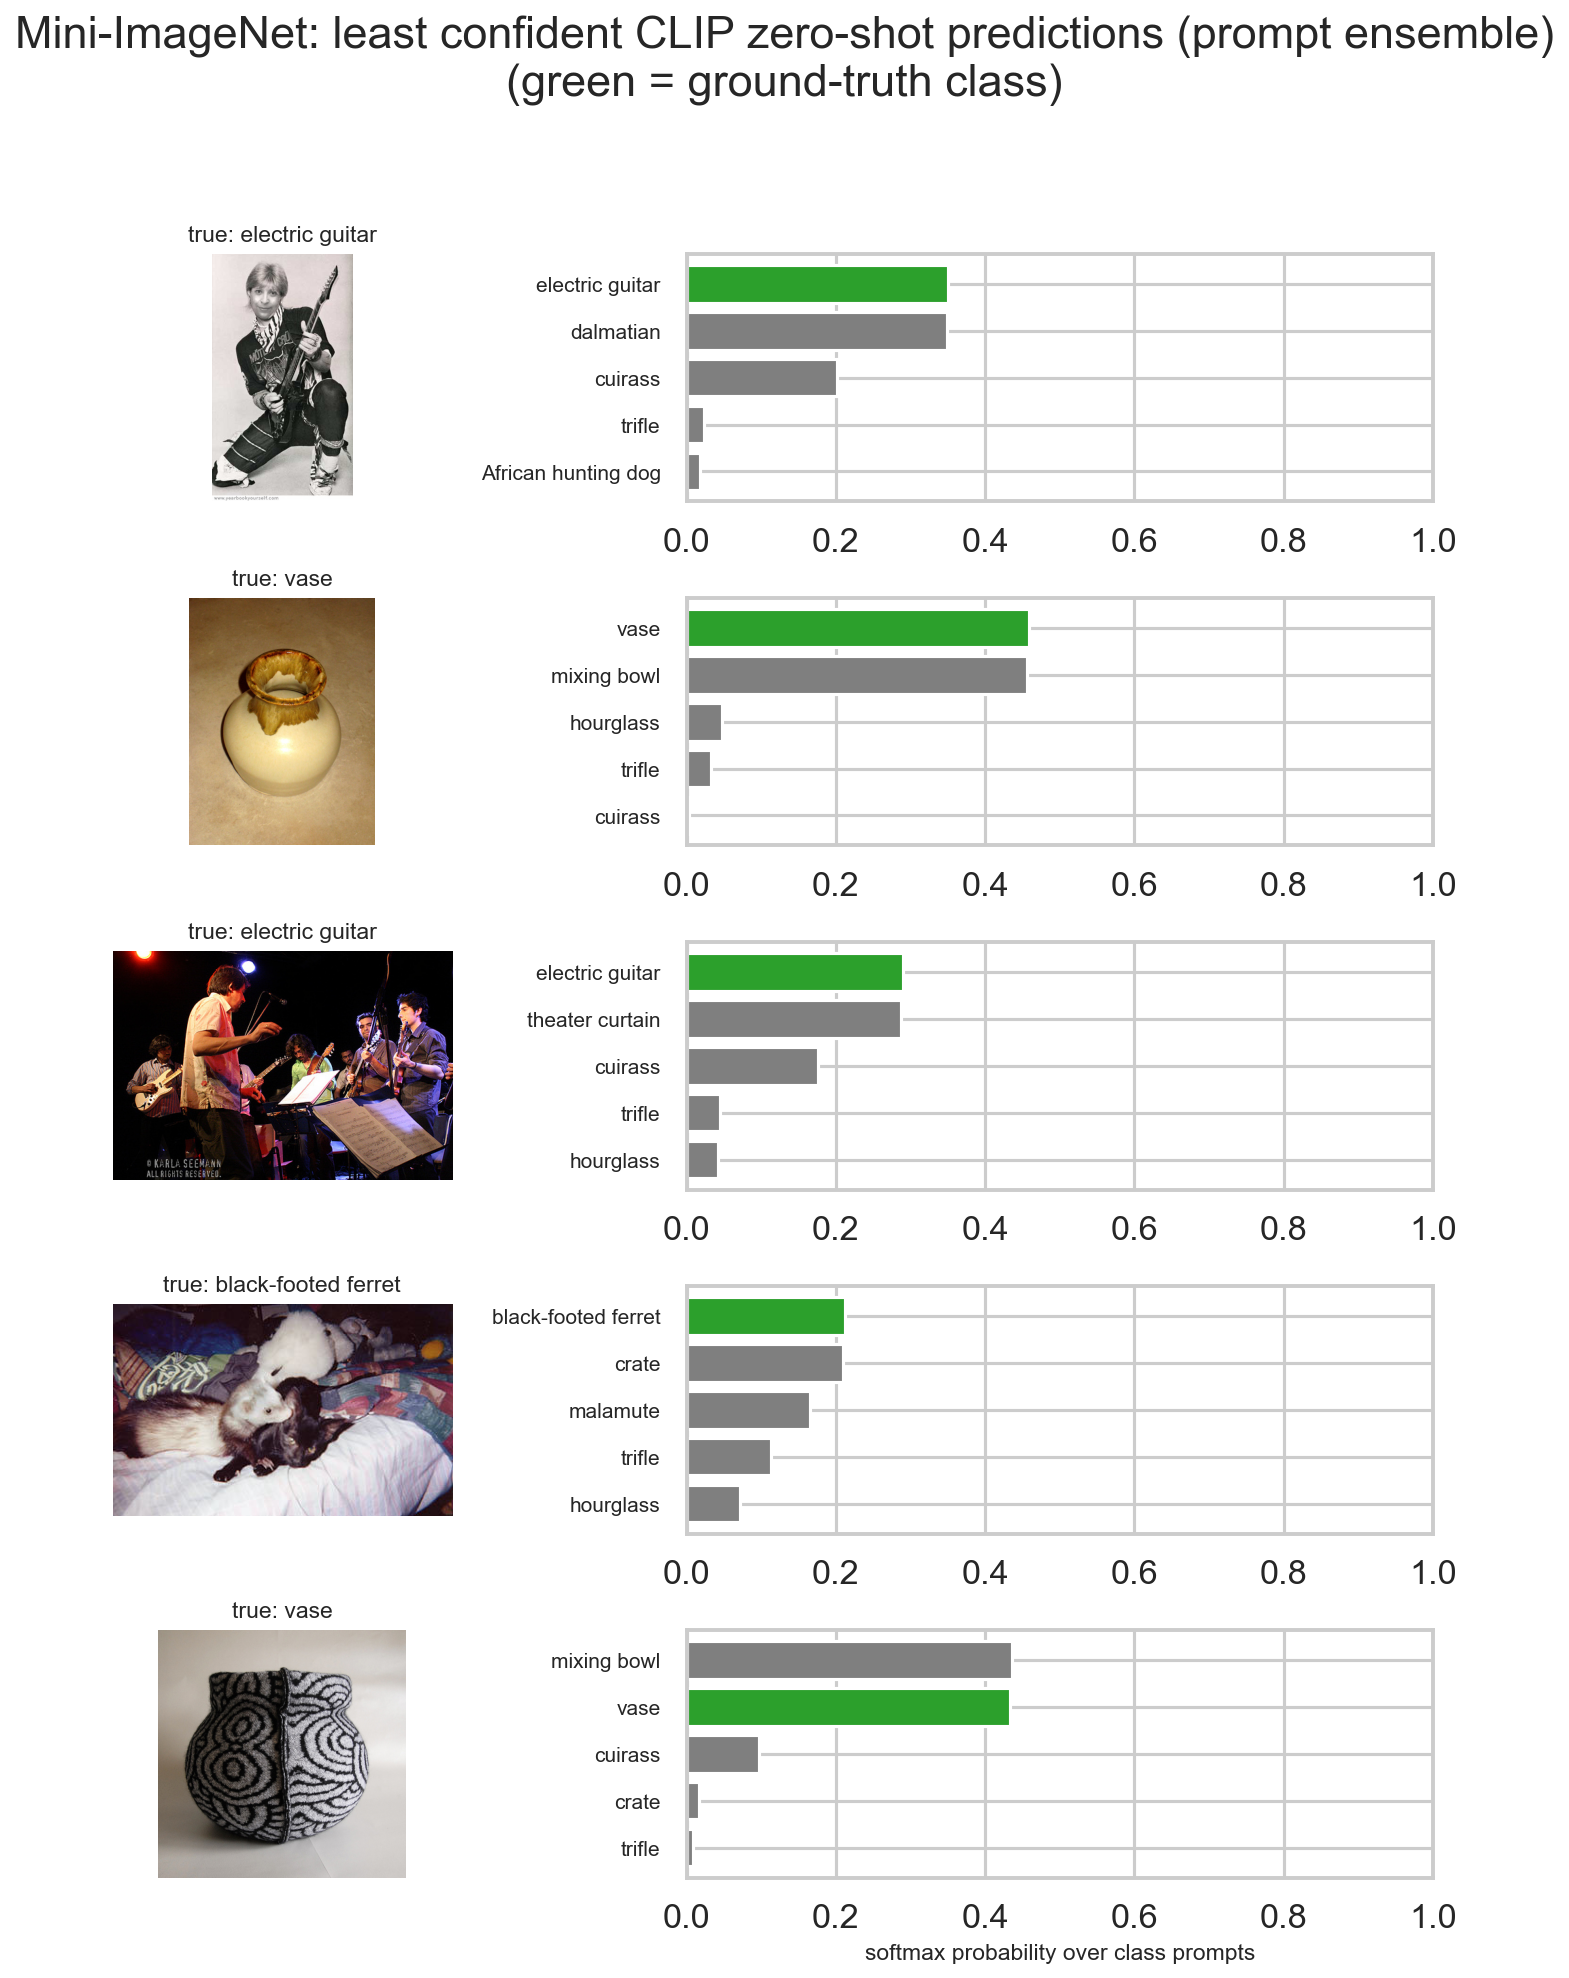

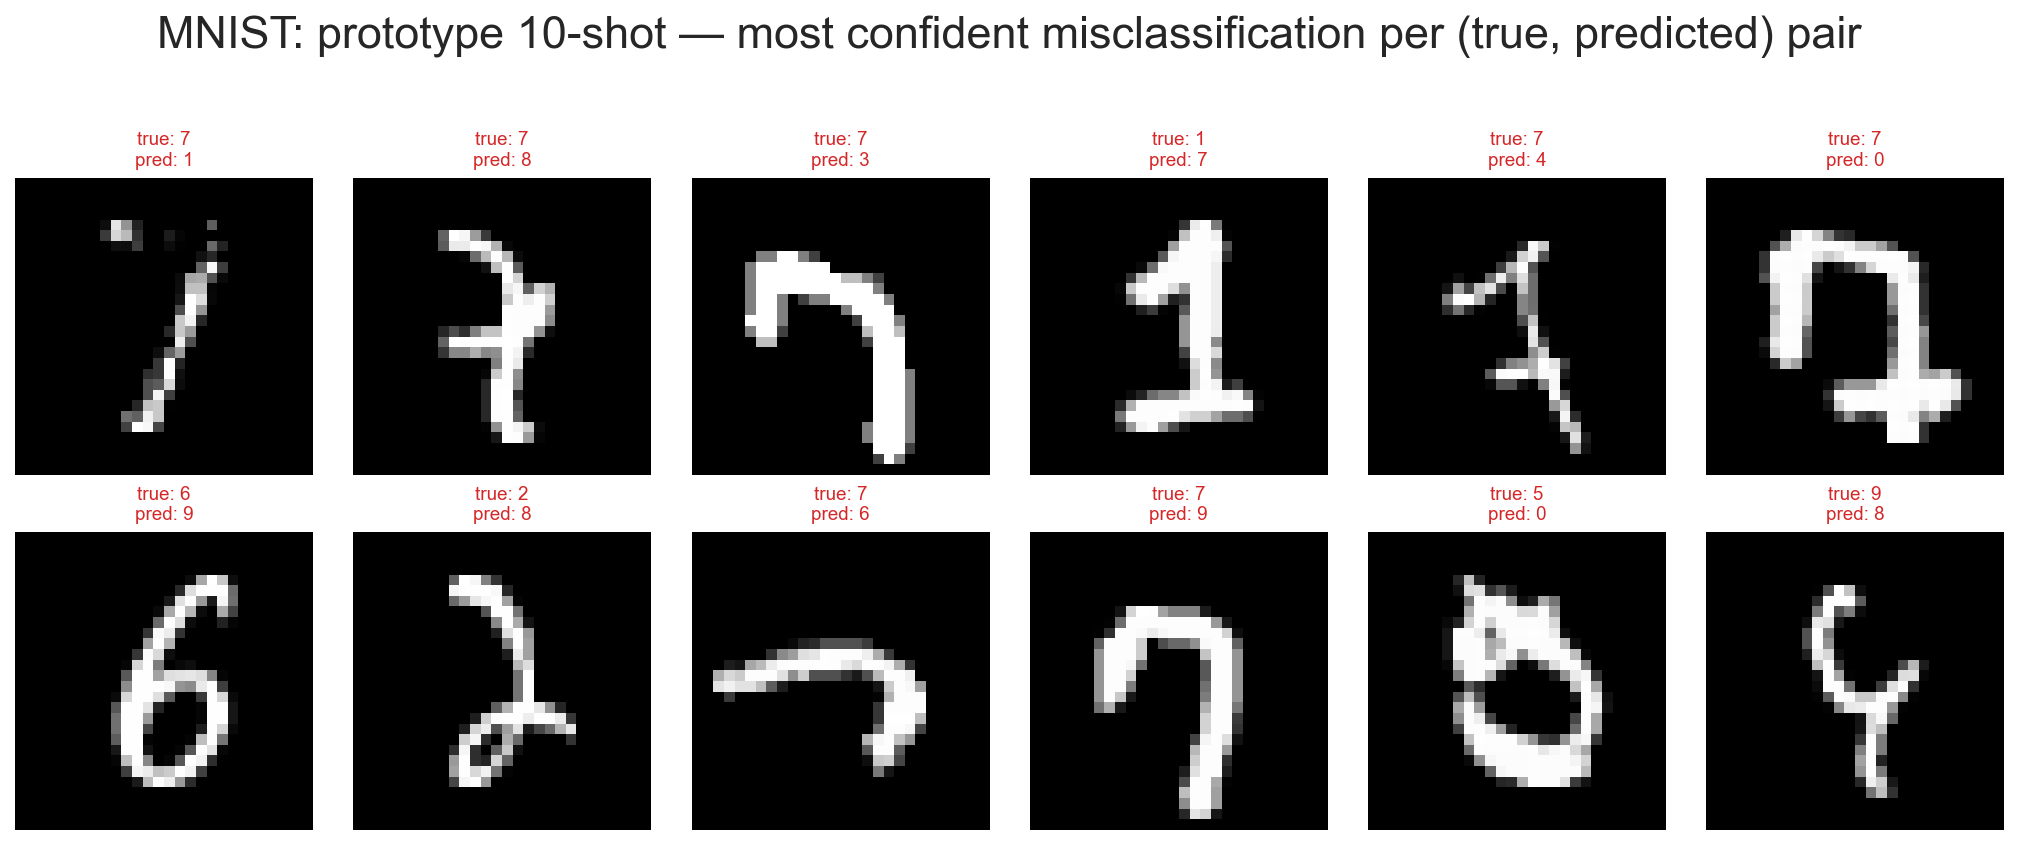

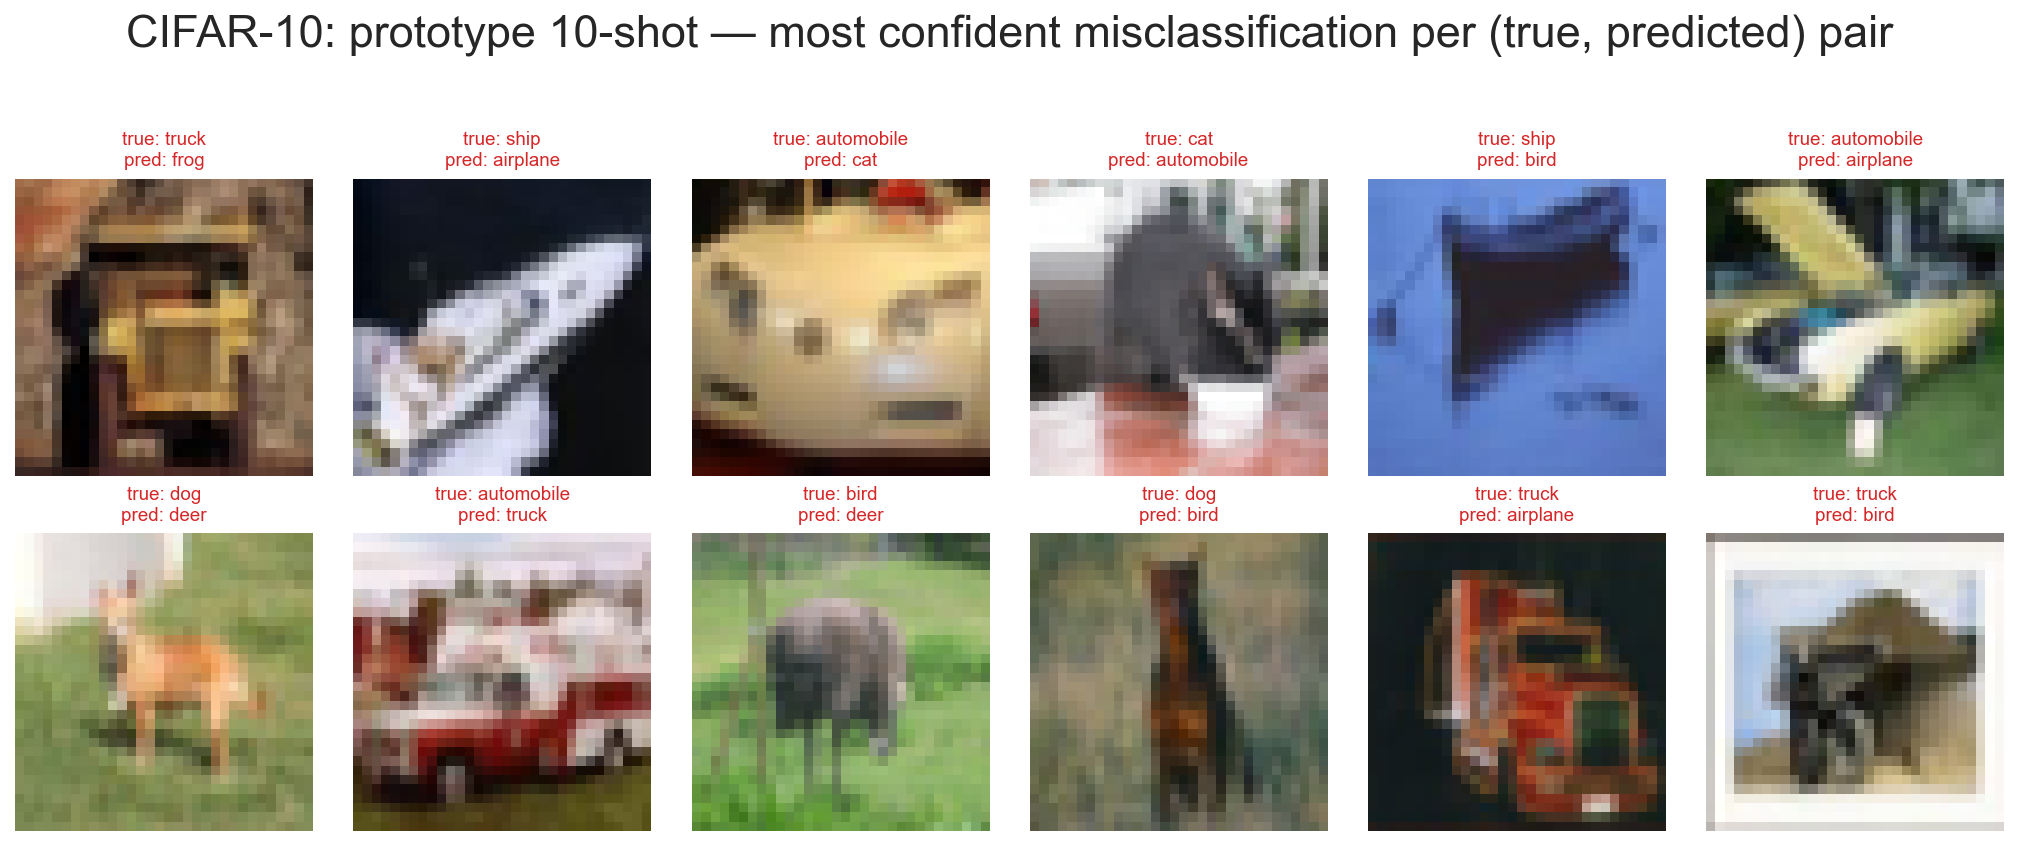

In [10]:
for name in ("confusion_mnist_proto10s.png", "confusion_cifar10_proto10s.png",
             "clip_zeroshot_cifar10.png", "clip_zeroshot_mini_imagenet.png",
             "failures_mnist.png", "failures_cifar10.png"):
    display(Image(str(REPO / "results" / "figures" / name), width=820))

## 6 · Protocol integrity & provenance

*(This section summarizes guarantees that live in the repository — ADRs, config, raw
artifacts — so the notebook is self-contained for review.)*

**Data separation.** Support/query indices per episode were sampled once, committed
(`results/artifacts/episodes/`), and are integrity-fingerprinted against the feature
caches at load time. Support and query sets are disjoint by construction; query labels
are used *only* for the final accuracy computation — never in training, prototype
construction, or any selection decision. For MNIST/CIFAR-10, simple-protocol support
comes from the train split and evaluation from the full test split.

**Stage 2 target policy (ADR 0003).** Every episodic class prototype is computed only
from that episode's support set, $c_k = \frac{1}{K}\sum_{x \in S_k} f(x)$. The cached
`prototypes_*.pt` artifacts are computed from **train splits only** (MNIST/CIFAR-10)
and exist for train-split use; no eval-split statistic may ever become a Flow-Matching
training target. Stage 2 trainable modules for Mini-ImageNet will train on the 64 R&L
train classes, tune on the 16 validation classes, and evaluate on the 20 test classes.
The encoder stays frozen in Stages 2–3.

**Hyperparameter provenance.** All hyperparameters were fixed a priori and never
adjusted after observing any test metric: linear probe = Adam, 300 steps, lr 0.01,
weight decay 0, init 0.01·N(0,1) (seeded), full-batch on the support set, loss =
per-episode mean CE (sum over episodes / S), identical configuration for every
dataset and K. Prompt templates come from the published OpenAI CLIP lists. No
hyperparameter or selection decision uses test data: the final embedding selection
(§7) runs on **validation episodes** — the 16 R&L validation classes for
Mini-ImageNet (their canonical purpose) and train-split episodes for MNIST/CIFAR-10
(seed 123, disjoint from all test evaluation).

**Paired statistical comparisons.** All methods share identical episodes, so method
comparisons use the per-episode accuracy *differences* (mean ± 95% CI), which is far
more informative than comparing two marginal CIs. Positive = linear probe beats the
cosine prototype on the same episodes:

In [11]:
import numpy as np

raw = REPO / "results" / "metrics" / "raw"
rows = []
for bb, bb_name in (("clip_vitb32", "CLIP"), ("dinov2_vits14", "DINOv2"), ("resnet50", "ResNet-50")):
    row = {"embeddings": bb_name}
    for ds in ("mnist", "cifar10", "mini_imagenet"):
        for k in (1, 5):
            a = np.load(raw / f"ep_{ds}_5w{k}s_linear__{bb}.npy")
            b = np.load(raw / f"ep_{ds}_5w{k}s_proto_cos__{bb}.npy")
            d = a - b
            ci = 1.96 * d.std(ddof=1) / np.sqrt(len(d))
            row[f"{ds} {k}s"] = f"{100 * d.mean():+.2f} ± {100 * ci:.2f}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("embeddings"))

,mnist 1s,mnist 5s,cifar10 1s,cifar10 5s,mini_imagenet 1s,mini_imagenet 5s
embeddings,,,,,,
CLIP,+3.40 ± 0.29,+8.59 ± 0.41,+3.94 ± 0.34,+1.66 ± 0.21,+2.26 ± 0.30,+0.56 ± 0.13
DINOv2,-5.59 ± 0.66,+4.57 ± 0.41,-4.58 ± 0.41,-1.27 ± 0.24,-1.50 ± 0.22,-0.41 ± 0.10
ResNet-50,+1.54 ± 0.38,+6.44 ± 0.38,-0.75 ± 0.48,-1.35 ± 0.33,-5.23 ± 0.36,-1.33 ± 0.15


On CLIP embeddings the probe wins every setting; on DINOv2 the prototype wins five of
six. The probe-vs-prototype ranking is **encoder-dependent** — see §7 for discussion.
(ResNet-50 × Mini-ImageNet cells are ImageNet-label-contaminated, as flagged in §5.)

## 7 · Discussion & handoff to Stage 2

Observations the tables above support (numbers auto-loaded from `results/metrics/`):

- **Frozen-embedding quality dominates.** Ranking across backbones follows embedding separability (§3, both the qualitative t-SNE and the quantitative metrics) — the classifier head matters less than the encoder. Note the setting throughout is *few-shot classification over frozen pretrained foundation-model embeddings*: near-ceiling Mini-ImageNet numbers are not comparable to the traditional few-shot literature, where encoders never see such broad pretraining. The strongest caveat is ResNet-50's ImageNet-1k *label* overlap with the R&L test classes; a weaker form (semantically overlapping pretraining data) applies to CLIP and DINOv2 too.
- **Zero-shot CLIP is a semantic reference baseline**, not an equivalent few-shot method: it consumes class *names* + pretrained image–text alignment, while the other heads consume labeled support *images*. It beats every CLIP-embedding support head on natural images (CIFAR-10, Mini-ImageNet) but is markedly weaker on MNIST digits — far from CLIP's training distribution — and the prompt ensemble even *hurts* there. A planned discussion point, not a bug.
- **Prototype vs. linear is encoder-dependent** (paired per-episode CIs, §6). Using CLIP embeddings the probe wins at every dataset × K; on DINOv2 the prototype wins five of six settings; on ResNet-50 the outcome is split. With a fixed a-priori training budget, no head is universally better — on MNIST's poorly separated embeddings extra shots favor the trained boundary, while on well-clustered embeddings the prototype is the more robust default, especially at K=1.

### Final embedding selection — the configurations Stage 2 must beat

Stage 1's purpose is **selection, not ranking**, and the selection is leakage-free: for each (dataset, head) **one** configuration is chosen across all K — by mean accuracy on **validation episodes** (Mini-ImageNet: the 16 R&L validation classes; MNIST/CIFAR-10: train-split episodes; seed 123) — with a paired per-episode check against the runner-up (statistical tie → the smaller embedding wins). Zero-shot CLIP is selected by *prompt variant* (single vs ensemble; K does not apply — it uses no support). The selected configuration's **test** numbers are then read out once as the Stage-2 reference (`results/artifacts/best_baselines.json`). ResNet-50 is excluded on Mini-ImageNet: the val classes are ImageNet-1k classes too, so selection would inherit the label contamination.

In [12]:
import json

with open(REPO / "results" / "artifacts" / "best_baselines.json") as f:
    best = json.load(f)["selection"]
rows = []
for ds, heads in best.items():
    for head, info in heads.items():
        test = " / ".join(f"{k}: {100 * v['acc']:.2f} ± {100 * v['ci95']:.2f}"
                          for k, v in info["test_reference"].items())
        rows.append({"dataset": ds, "head": head,
                     "selected (on validation)": info["classifier"],
                     "val acc (mean over K)": f"{100 * info['val_acc_mean']:.2f}",
                     "margin vs runner-up": info["paired_margin_vs_runner_up"]
                     + (" (tie → smaller emb.)" if info["tie_break_smaller_embedding"] else ""),
                     "test reference (one-time read-out)": test})
display(pd.DataFrame(rows))

,dataset,head,selected (on validation),val acc (mean over K),margin vs runner-up,test reference (one-time read-out)
0,mnist,prototype,proto_eucl__clip_vitb32,65.90,+0.04 ± 0.07 (tie → smaller emb.),1shot: 56.64 ± 0.87 / 5shot: 77.93 ± 0.60
1,mnist,linear,linear__clip_vitb32,72.31,+2.51 ± 0.50,1shot: 59.96 ± 0.86 / 5shot: 86.60 ± 0.44
2,mnist,zeroshot_clip,clip_zeroshot__clip_vitb32,59.38,+2.96 ± 0.55,1shot: 59.61 ± 0.88 / 5shot: 59.53 ± 0.89
3,cifar10,prototype,proto_cos__dinov2_vits14,85.16,+1.16 ± 0.18,1shot: 77.34 ± 0.72 / 5shot: 91.95 ± 0.37
4,cifar10,linear,linear__clip_vitb32,84.15,+1.67 ± 0.44,1shot: 76.86 ± 0.80 / 5shot: 90.82 ± 0.37
5,cifar10,zeroshot_clip,clip_zeroshot_ens__clip_vitb32,93.07,+0.24 ± 0.07,1shot: 93.44 ± 0.27 / 5shot: 93.22 ± 0.27
6,mini_imagenet,prototype,proto_cos__dinov2_vits14,95.62,+0.43 ± 0.11,1shot: 94.42 ± 0.47 / 5shot: 98.56 ± 0.15
7,mini_imagenet,linear,linear__clip_vitb32,95.19,+0.67 ± 0.26,1shot: 91.40 ± 0.57 / 5shot: 98.26 ± 0.16
8,mini_imagenet,zeroshot_clip,clip_zeroshot_ens__clip_vitb32,99.05,+0.06 ± 0.03,1shot: 99.08 ± 0.10 / 5shot: 99.10 ± 0.10


### Advised Stage-2/3 architectures

Each variant is built on **its dataset's selected embedding** (table above) and must beat that configuration, paired on the same episode files:

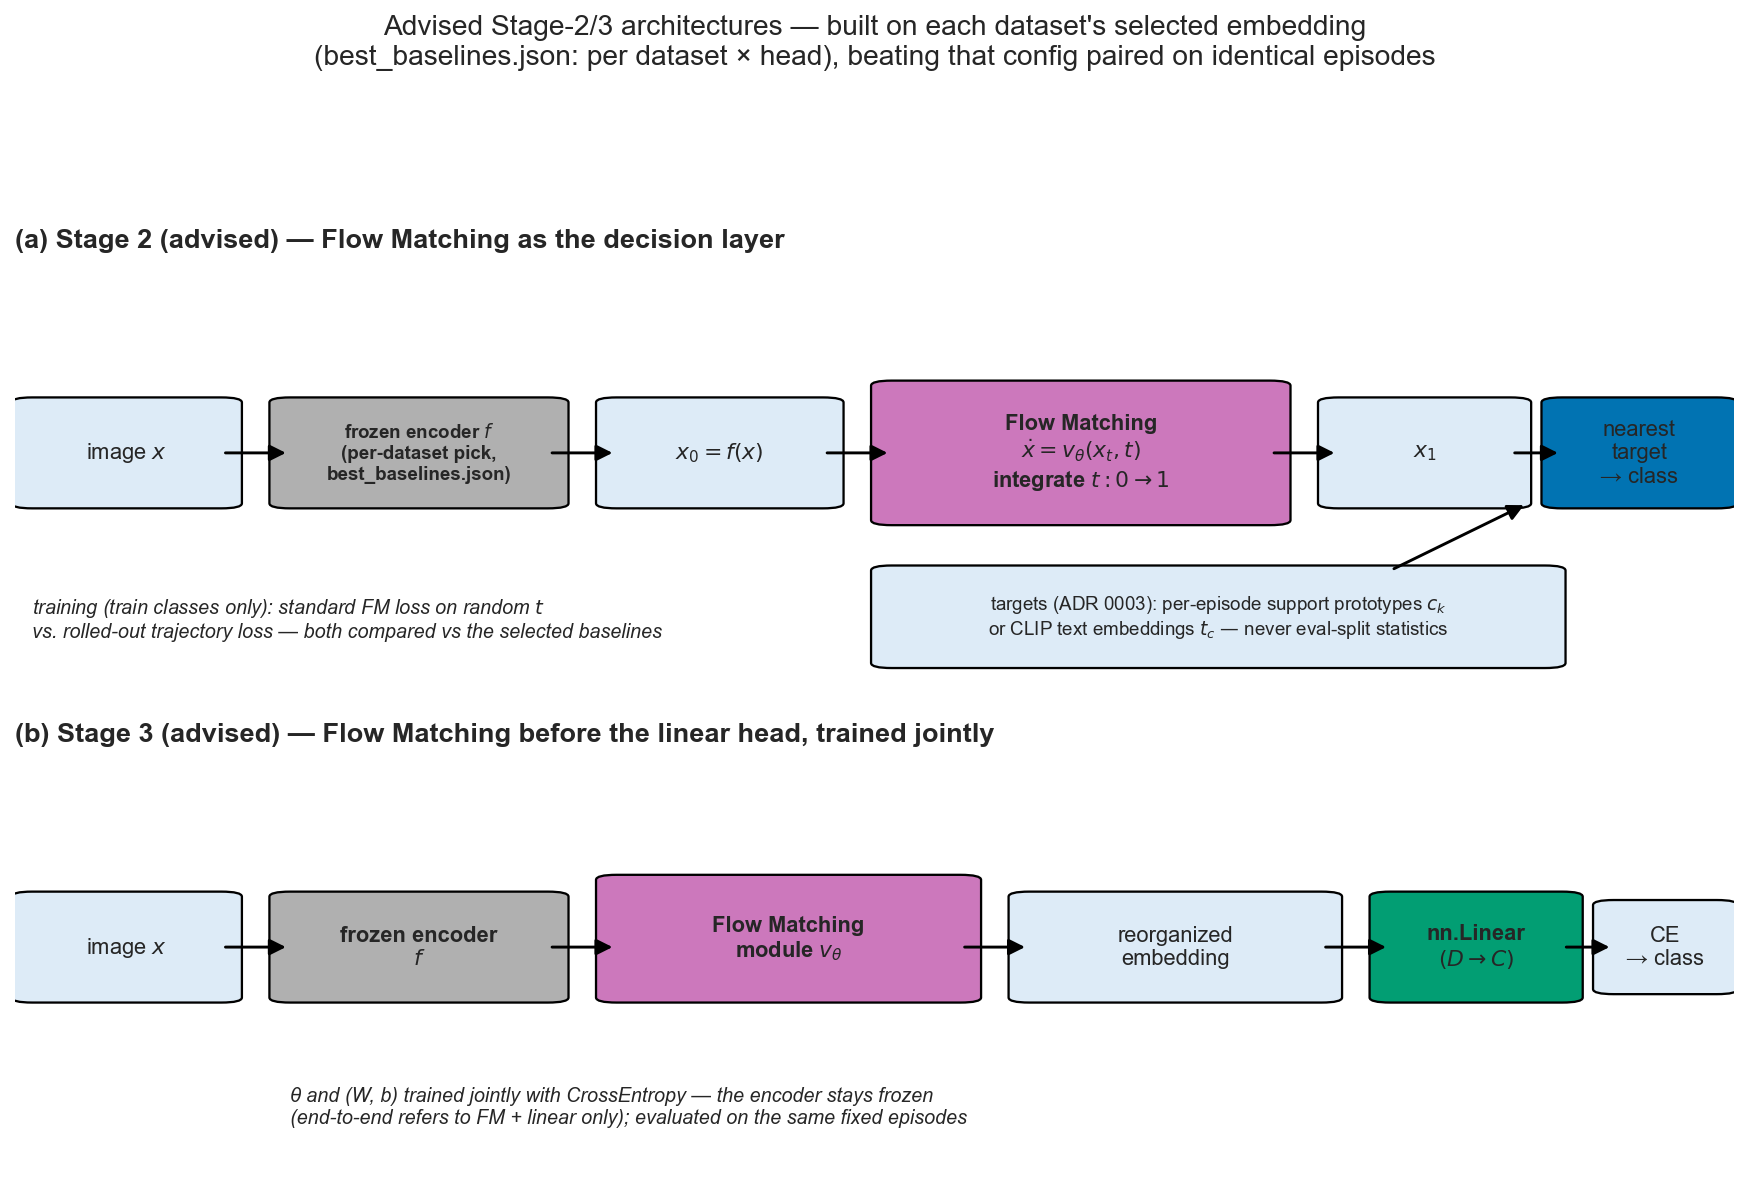

In [13]:
display(Image(str(REPO / "results" / "figures" / "arch_stage2_advised.png"), width=920))

**Artifacts handed to Stage 2/3** (all committed or reproducible via `tasks.ps1 extract`):

| Artifact | Path |
|---|---|
| Fixed episode indices | `results/artifacts/episodes/*.pt` |
| Class prototypes (per dataset/split/backbone) | `results/artifacts/prototypes_*.pt` |
| CLIP text embeddings (primary + ensemble) | `results/artifacts/clip_text_*.pt` |
| Cached embeddings | `results/features/*.pt` (regenerable) |

Stage 2 replaces the decision layer with a Flow-Matching transport toward prototypes / text embeddings; Stage 3 inserts FM before the linear head, trained end-to-end — both evaluated on the **same episode files** for an exact comparison.